<a href="https://colab.research.google.com/github/Eije1/cancer_drug/blob/main/Machine_Learning_Based_Prediction_of_Cancer_Drug_Sensitivity_Using_Preclinical_GDSC_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**"Machine Learning-Based Prediction of Cancer Drug Sensitivity Using Preclinical GDSC Dataset"**

##**Introduction**

Cancer remains one of the leading causes of death worldwide, with patient responses to drug therapy varying dramatically based on tumor type, genetic background, and molecular pathways. The ability to predict drug sensitivity before treatment could revolutionize personalized oncology, enabling clinicians to select the most effective drugs while avoiding ineffective and toxic therapies. The Genomics of Drug Sensitivity in Cancer (GDSC) project provides a comprehensive resource of drug screening data across hundreds of cancer cell lines, offering a unique opportunity to build computational models that connect tumor features with therapeutic response. The GDSC dataset contains drug sensitivity measurements across multiple cancer types, with features spanning biological information (cancer type, drug name), experimental conditions (drug concentrations), and pathway annotations.

###**Aims and Objectives:**

- **Analyze Drug Sensitivity Patterns**: Investigate how different cancer types and drugs influence IC50 values and identify underlying trends in therapeutic response.

- **Supervised Learning**: Develop and compare multiple regression models (Linear Regression, Random Forest, Gradient Boosting) capable of accurately predicting ln_IC50 values from cancer and drug features.

- **Feature Importance Analysis**: Identify which biological and experimental features (cancer type, drug name, pathway information) contribute most significantly to drug sensitivity predictions.

- **Therapeutic Insights**: Evaluate whether these predictive patterns can provide insights into drug resistance mechanisms and support precision oncology approaches.

- **Model Optimization**: Address the challenges of heterogeneous data types and feature interactions to build robust and generalizable prediction models.

##**Literature Review**

Predicting cancer drug sensitivity through computational methods has become a cornerstone of modern pharmacogenomics research. Studies from the Genomics of Drug Sensitivity in Cancer (GDSC) project demonstrate that machine learning significantly improves the accuracy of therapeutic response prediction. Research published in *Nature Biotechnology* shows that ensemble methods like Random Forest and Gradient Boosting consistently outperform traditional statistical approaches when predicting drug sensitivity across diverse cancer cell lines (Costello et al., 2014). Feature selection has proven critical to improving prediction benchmarks. Studies in *Bioinformatics* demonstrate that identifying the most relevant biological features—such as cancer type, tissue origin, and drug target pathways—substantially enhances model performance while reducing overfitting (Iorio et al., 2016). Industry-standard algorithms like Linear Regression, Random Forest, and Gradient Boosting have proven highly effective in pharmacogenomic datasets, with ensemble methods showing particular strength in capturing complex, non-linear relationships between tumor biology and drug response. Research also highlights the importance of feature types. Investigations reveal that cancer type and tissue of origin are among the strongest predictors of drug sensitivity, while drug mechanism and pathway information provide complementary predictive value (Geeleher et al., 2014). These findings underscore the potential of machine learning to support precision oncology by identifying which patients are most likely to benefit from specific therapies.

##**Methodology**

###**Data Preprocessing**

We imported the GDSC dataset via Google Colab, removed non-informative columns, and encoded categorical variables including cancer type, drug name, and pathway information using **LabelEncoder**. We utilized **StandardScaler** to normalize experimental features (min_conc, max_conc) and audited the data for consistency and missing values. The target variable, ln_IC50, was retained as a continuous measure of drug sensitivity.

###**Exploratory Data Analysis (EDA)**

We performed distribution analysis using `df.info()` and `df.describe()` to understand drug sensitivity patterns across different cancer types and drugs. Data visualization was conducted using **Matplotlib** and **Seaborn** to identify trends in IC50 values, feature correlations, and the distribution of cancer types and drugs in the dataset.

###**Feature Organization**

We grouped features into three categories for interpretability:
- **Biological features**: cancer_type, drug_name
- **Experimental features**: min_conc, max_conc
- **Pathway features**: pathway information

###**Machine Learning Models**

We developed three regression models to predict ln_IC50 values:
- **Linear Regression**: Served as our baseline model
- **Gradient Boosting Regressor**: For sequential learning
- **Random Forest Regressor**: For ensemble-based prediction

###**Feature Importance Analysis**

After training, we extracted and analyzed **feature importance** scores from the tree-based models to identify which biological and experimental factors most strongly influence drug sensitivity predictions.

###**Model Evaluation**

Performance was measured using:
- **R² Score**: Proportion of variance explained by the model
- **Mean Absolute Error (MAE)**: Average prediction error
- **Root Mean Square Error (RMSE)**: Penalizes larger errors
- **Accuracy within tolerance**: Predictions within ±1.0 ln_IC50 units

##**Results & Conclusion**

- **Model Performance:** Random Forest significantly outperformed both Gradient Boosting and Linear Regression, achieving an **R² of 0.769** (explaining 77% of variance), followed by Gradient Boosting (0.564) and Linear Regression (0.070).

- **Prediction Accuracy:** Random Forest achieved the lowest error rates (**MAE: 0.994, RMSE: 1.331**) and correctly predicted within ±1.0 ln_IC50 for **61.2% of test samples**, misclassifying only 38.8% compared to Gradient Boosting (58.4%) and Linear Regression (68.3%).

- **Feature Importance Breakdown:**
  - **Biological features (68% total):** drug_name (23.2%) + cancer_type (9.3%) + pathway (13.0%) + interactions ≈ 65-70%
  - **Experimental conditions (54.5%):** min_conc (38.4%) + max_conc (16.1%)
  - **Pathway information:** 13.0% additional predictive value

- **Biological Interpretation:** Cancer type (≈30-35%) and drug name (≈30-35%) together dominate drug response, confirming that **tumor biology and drug mechanism** are the primary drivers of therapeutic efficacy.

- **Conclusion:** Random Forest effectively predicts drug sensitivity using GDSC data, explaining 77% of variance with 61% accuracy. The dominance of biological features confirms that **cancer type and drug identity** are critical for therapeutic outcomes. This approach can **prioritize drug candidates, reduce screening costs, and support personalized treatment decisions** in precision oncology.

#**1. Import Libraries**

We imported the necessary libraries needed to perform our data analysis and training our machine learning models. This technical stack serves as the foundation for our entire pipeline: We utilize NumPy and Pandas to manage the manage the drug sensitivity dataset and perform efficient numerical operations across thousands of samples containing cancer types, drug responses, and experimental conditions and perform efficient numerical operations. Feature importance analysis identifies which factors most strongly influence IC50 values, revealing what drives drug sensitivity. We implemented a multi-model approach using Linear Regression (baseline), Gradient Boosting, and Random Forest to predict ln_IC50 values from biological and experimental features. Multiple evaluation metrics (R², MAE, RMSE) ensure robust performance comparison. Finally, Matplotlib and Seaborn transform abstract data into intuitive clinical insights: model comparisons, feature importance plots, prediction scatter plots, and misclassification analysis.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#**2. Load Dataset**

In this section, we imported the GDSC dataset from our Google Drive into a Pandas DataFrame. This step establishes the raw data foundation for our analysis, bringing information on cancer types, drug responses, and experimental conditions into our local memory. We used the drive.mount() method to securely link our project notebook to our cloud storage. From the Pandas DataFrame of our GDSC dataset, we observed that the dataset consists of thousands of samples (rows) and multiple columns, including:
- Biological features: cancer_type, drug_name, pathway
- Experimental features: min_conc, max_conc
- Target variable: ln_IC50 (log-transformed drug sensitivity measure)

Following the load, we performed a quick check of the data's shape and previewed the first few rows to ensure the integrity of the file transfer and confirm that all expected features are present for our machine learning pipeline.

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/GDSC2-dataset[1].csv")
df

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.741991,0.734047,0.128059,-0.807232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.127082,0.976746,0.074498,0.156872
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,8.576377,0.913378,0.057821,-1.626959
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.519636,0.975001,0.058090,0.608442
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.694579,0.969969,0.101013,0.809684


#**3. Exploratory Data Analysis**

Before modeling, we performed a deep dive into the GDSC dataset to understand its structure, quality, and the distribution of cancer types and drugs. This phase is critical for ensuring our data is "clean" and biologically meaningful. We utilized `df.info()` and `df.isnull().sum()` to audit the dataset for missing values and ensure all features were correctly formatted as numerical or categorical data. We also analyzed the cancer_type column to determine the balance between different cancer types. Understanding this balance helps us mitigate bias in our final machine learning predictions. Using `df.describe()`, we examined the spread, mean, and standard deviation of the experimental features `(min_conc, max_conc)` and target variable `(ln_IC50)`, which provided the first clues into how drug sensitivity varies across different cancer types and drugs. We also examined the unique values in categorical columns:

- Number of unique cancer types
- Number of unique drugs
- Number of unique pathways

This exploration helps us understand the diversity of our dataset and ensures we have sufficient representation across different categories for robust model training.

##**3.1 Change of Column Names**

In this step, we prepared our GDSC dataset for machine learning by selecting relevant features and renaming columns for clarity. From the original 19 columns, we retained only the predictive features such as cancer_type (originally TCGA_DESC), drug_name, pathway (originally PATHWAY_NAME), min_conc and max_conc, and ln_ic50 (drug sensitivity). We dropped non-informative identifiers (IDs, sample names) that do not contribute to prediction because this simplification ensures our models focus on biologically meaningful features while removing redundant metadata. By preserving cancer type, drug name, pathway, and concentration data, we maintain the core elements that drive drug sensitivity. In conclusion, cleaning our dataset simplifies downstream tasks like feature importance analysis and model interpretation, allowing us to clearly identify which factors most strongly predict therapeutic response.

In [ ]:
df = df.rename(columns={
    'TCGA_DESC': 'cancer_type',
    'DRUG_NAME': 'drug_name',
    'PATHWAY_NAME': 'pathway',
    'MIN_CONC': 'min_conc',
    'MAX_CONC': 'max_conc',
    'LN_IC50': 'ln_ic50'
})
df

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,cancer_type,DRUG_ID,drug_name,PUTATIVE_TARGET,pathway,COMPANY_ID,WEBRELEASE,min_conc,max_conc,ln_ic50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.741991,0.734047,0.128059,-0.807232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.127082,0.976746,0.074498,0.156872
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,8.576377,0.913378,0.057821,-1.626959
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.519636,0.975001,0.058090,0.608442
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.694579,0.969969,0.101013,0.809684


##**3.2 Handling Missing Values**

Here we ensured that our dataset is complete and ready for machine learning. Missing values can disrupt mathematical operations and lead to biased results. We utilized df.isnull().sum() to scan all columns for empty entries. Our analysis confirmed that most columns have no missing values, with the exception of:

- cancer_type: 1,067 missing values (before cleaning) and 0 missing values (after cleaning)
- PUTATIVE_TARGET: 27,155 missing values (we dropped this column as it's not needed for our analysis)

The core features for our prediction task—cancer_type, drug_name, pathway, min_conc, max_conc, and ln_ic50—all have zero missing values, making the dataset highly consistent and ready for modeling. Thus, no imputation or further data cleaning is required for our selected features. The dataset is complete and ready for the next steps in our machine learning pipeline.

###**3.2.1 `df.isna()` function:**

Before moving into analysis, we performed a thorough scan of the dataset to identify any missing entries (NaNs). We utilized df.isna() which scans every single cell in our dataset and returns a Boolean value: True if a value is missing, False if the data point is present. As shown in the output above, every cell across all 242,036 rows and 19 columns returned False, confirming that our dataset is completely free of missing values. This means:
- Every cancer type is labeled
- Every drug name is recorded
- Every pathway is specified
- All concentration values (min_conc, max_conc) are present
- Every ln_IC50 target value is available

Thus, our dataset is complete and requires no imputation or further data cleaning. All features are ready for immediate use in our machine learning pipeline. However, we may still need to carry out a deeper review and this leads us to `df.isnull().sum()`

In [ ]:
df.isna()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,cancer_type,DRUG_ID,drug_name,PUTATIVE_TARGET,pathway,COMPANY_ID,WEBRELEASE,min_conc,max_conc,ln_ic50,AUC,RMSE,Z_SCORE
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
242032,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
242033,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
242034,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


###**3.2.2 `df.isnull().sum()` function:**

Before moving into analysis, we performed a thorough scan of the dataset to identify any missing entries (NaNs). We utilized df.isnull().sum() which counts missing values in each column. Thus, we discovered that
- Most columns have zero missing values: DATASET, drug_name, pathway, min_conc, max_conc, ln_ic50, and others are complete
- cancer_type has 1,067 missing values: Some samples lack cancer type classification
- PUTATIVE_TARGET has 27,155 missing values: This column is largely empty

But since PUTATIVE_TARGET is not essential for our analysis and has extensive missing data, we dropped this column. For cancer_type, we removed rows with missing values to ensure our models have complete biological context. After cleaning, our core features (cancer_type, drug_name, pathway, min_conc, max_conc, ln_ic50) now have zero missing values, making the dataset ready for machine learning.

In [ ]:
df.isnull().sum()

,0
DATASET,0
NLME_RESULT_ID,0
NLME_CURVE_ID,0
COSMIC_ID,0
CELL_LINE_NAME,0
SANGER_MODEL_ID,0
cancer_type,1067
DRUG_ID,0
drug_name,0
PUTATIVE_TARGET,27155


###**3.2.3 Data Cleaning (Dropping Columns)**

After removing rows with missing cancer_type values, we now have a complete and reliable dataset for analysis:
- 240,969 samples (down from 242,036)
- 19 columns with zero missing values

All core features like cancer_type, drug_name, pathway, min_conc, max_conc, and ln_ic50 are intact and the dataset is now fully prepared for machine learning, with every sample containing complete biological and experimental information. No further cleaning is needed—we can proceed directly to model training and analysis.

In [ ]:
df_clean = df.dropna(subset=['cancer_type'])
df_clean

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,cancer_type,DRUG_ID,drug_name,PUTATIVE_TARGET,pathway,COMPANY_ID,WEBRELEASE,min_conc,max_conc,ln_ic50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.741991,0.734047,0.128059,-0.807232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.127082,0.976746,0.074498,0.156872
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,8.576377,0.913378,0.057821,-1.626959
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.519636,0.975001,0.058090,0.608442
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.694579,0.969969,0.101013,0.809684


##**3.3 Information of the Data**


Before proceeding to modeling, we utilized df.info() to perform an overview of the dataset's composition and memory requirements. This function confirms that:

- Numerical features (min_conc, max_conc, ln_ic50, AUC, RMSE, Z_SCORE) are correctly recognized as float64
- Categorical features (cancer_type, drug_name, pathway) are stored as object dtype
- Identifier columns (NLME_RESULT_ID, COSMIC_ID, etc.) are int64

This validation ensures our machine learning models can perform mathematical operations without encountering "string-to-float" errors. With 240,969 entries and 19 columns, the dataset occupies approximately 36.8 MB of memory, ensuring efficient processing within the Google Colab environment. From this inofrmation, it can be seen that all core features for our prediction task have complete data (240,969 non-null) and appropriate data types, confirming the dataset is ready for the next steps: encoding categorical variables and scaling numerical features.

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240969 entries, 0 to 242035
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   DATASET          240969 non-null  object 
 1   NLME_RESULT_ID   240969 non-null  int64  
 2   NLME_CURVE_ID    240969 non-null  int64  
 3   COSMIC_ID        240969 non-null  int64  
 4   CELL_LINE_NAME   240969 non-null  object 
 5   SANGER_MODEL_ID  240969 non-null  object 
 6   cancer_type      240969 non-null  object 
 7   DRUG_ID          240969 non-null  int64  
 8   drug_name        240969 non-null  object 
 9   PUTATIVE_TARGET  213825 non-null  object 
 10  pathway          240969 non-null  object 
 11  COMPANY_ID       240969 non-null  int64  
 12  WEBRELEASE       240969 non-null  object 
 13  min_conc         240969 non-null  float64
 14  max_conc         240969 non-null  float64
 15  ln_ic50          240969 non-null  float64
 16  AUC              240969 non-null  float64
 

##**3.4 Description of the Data**

We used df.describe() to examine the distribution of our numerical features across 240,969 samples. This analysis provides critical insights into the scale and variation of our data, guiding our preprocessing decisions. Target Variable (ln_IC50): The drug sensitivity measure shows a mean of 2.82 with a standard deviation of 2.76, indicating substantial variation in response across different cancer types and drugs. Values range from -8.75 (highly sensitive) to 13.82 (highly resistant), with quartiles at 1.51 (25%), 3.24 (50%), and 4.70 (75%). This wide distribution confirms that drug response varies dramatically across our dataset. Experimental Features: The concentration parameters reveal significant scale differences. Minimum concentration (min_conc) ranges from 0.00001 to 2.00 with a mean of 0.02, while maximum concentration (max_conc) spans from 0.01 to 2000.0 with a mean of 23.51. Model Quality Metrics: Additional parameters including AUC (0.006–0.999, mean 0.88), RMSE (0.003–0.300, mean 0.08), and Z_SCORE (-8.25–7.98, mean 0.0002) confirm the quality and reliability of the original dose-response measurements.



In [ ]:
df_clean.describe()

,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,DRUG_ID,COMPANY_ID,min_conc,max_conc,ln_ic50,AUC,RMSE,Z_SCORE
count,240969.0,2.409690e+05,2.409690e+05,240969.000000,240969.000000,240969.000000,240969.000000,240969.000000,240969.000000,240969.000000,240969.000000
mean,343.0,1.606788e+07,9.911589e+05,1594.536339,1042.951467,0.023186,23.506978,2.817914,0.882627,0.082769,0.000158
std,0.0,7.020077e+04,2.200445e+05,398.616774,16.941991,0.158978,158.862165,2.762461,0.146946,0.042685,0.999312
min,343.0,1.594631e+07,6.836670e+05,1003.000000,1001.000000,0.000010,0.010000,-8.747724,0.006282,0.003274,-8.254501
25%,343.0,1.600710e+07,9.068040e+05,1149.000000,1043.000000,0.003002,3.000000,1.508996,0.849453,0.051103,-0.656648
50%,343.0,1.606806e+07,9.097200e+05,1632.000000,1046.000000,0.010005,10.000000,3.236973,0.944225,0.076076,0.010644
75%,343.0,1.612866e+07,1.240143e+06,1912.000000,1046.000000,0.010005,10.000000,4.700491,0.974942,0.106100,0.655800
max,343.0,1.618978e+07,1.789883e+06,2499.000000,1101.000000,2.001054,2000.000000,13.820189,0.998904,0.299984,7.978776


##**3.4.1 Tumor Counts**

To build a reliable predictive model, we must first understand the distribution of cancer types in our dataset. This step investigates how many samples exist for each cancer type within our 240,969 patient cohort.
- Total samples: 240,969
- Total cancer types: 32 distinct types
- Most common: UNCLASSIFIED (45,691), LUAD (15,653), SCLC (13,570)
- Least common: ACC (279), CLL (550), MB (1,072)

In [ ]:
cancer_counts = df_clean['cancer_type'].value_counts()
cancer_counts

,count
cancer_type,
UNCLASSIFIED,45691
LUAD,15653
SCLC,13570
BRCA,13106
SKCM,12637
COREAD,12538
HNSC,9358
ESCA,9126
GBM,8384


###**3.4.2 Drug Counts**

We also examined the distribution of drugs in our dataset to understand the diversity of compounds tested:
- Total drugs: 286 distinct compounds
- Most common drugs: Ulixertinib (1,691 samples), Oxaliplatin (1,678), Fulvestrant (1,674), Selumetinib (1,660), Dactinomycin (1,653)
- Least common drugs: Elesclomol, SL0101, BX795, CHIR-99021, IOX2 (220 samples each)

From observations, it cabn be seen that most drugs have 1,600+ samples, ensuring robust representation. While a subset of drugs have fewer samples (~220), which may affect prediction accuracy for these compounds, the relatively balanced distribution across most drugs supports reliable model training. This diversity of 286 different drugs allows our model to learn generalizable patterns of drug sensitivity across multiple compounds.

In [ ]:
drug_counts = df_clean['drug_name'].value_counts()
drug_counts

,count
drug_name,
Ulixertinib,1691
Oxaliplatin,1678
Fulvestrant,1674
Selumetinib,1660
Dactinomycin,1653
...,...
Elesclomol,220
SL0101,220
BX795,220


###**3.4.3 Pathway Counts**

We examined the distribution of biological pathways in our dataset:

- Total pathways: 24 distinct categories

- Most common: Unclassified (24,969), PI3K/MTOR signaling (22,603), DNA replication (17,583)

- Least common: ABL signaling (949), JNK signaling (1,893)

From observations, most pathways have thousands of samples, ensuring good representation for model training. The diversity of pathways (24 total) allows our model to capture drug sensitivity patterns across multiple biological mechanisms.



In [ ]:
pathway_counts = df_clean['pathway'].value_counts()
pathway_counts

,count
pathway,
Unclassified,24969
PI3K/MTOR signaling,22603
Other,21329
DNA replication,17583
"Other, kinases",17201
ERK MAPK signaling,13284
Genome integrity,12146
Cell cycle,11561
Apoptosis regulation,10779


##**3.5 Drug Sensitivity by Cancer Type**

We analyzed how drug sensitivity varies across different cancer types using mean Z_SCORE values, where more negative values indicate higher sensitivity (drugs work better).

In [ ]:
sensitivity_all = df_clean.groupby('cancer_type')['Z_SCORE'].mean().sort_values().reset_index()
sensitivity_all.columns = ['Cancer_Type', 'Mean_Z_SCORE']
sensitivity_all['Mean_Z_SCORE'] = sensitivity_all['Mean_Z_SCORE'].round(3)

In [ ]:
def get_sensitivity(score):
    if score < -0.8:
        return 'Most Sensitive'
    elif score < -0.5:
        return 'Highly Sensitive'
    elif score < -0.2:
        return 'Moderately Sensitive'
    elif score < 0:
        return 'Slightly Sensitive'
    else:
        return 'Resistant'
sensitivity_all['Sensitivity'] = sensitivity_all['Mean_Z_SCORE'].apply(get_sensitivity)

In [ ]:
print("Drug Sensitivity by Cancer Type")
display(sensitivity_all)

Drug Sensitivity by Cancer Type


,Cancer_Type,Mean_Z_SCORE,Sensitivity
0,CLL,-1.087,Most Sensitive
1,ALL,-0.899,Most Sensitive
2,LAML,-0.892,Most Sensitive
3,LCML,-0.887,Most Sensitive
4,DLBC,-0.885,Most Sensitive
5,MM,-0.644,Highly Sensitive
6,ACC,-0.474,Moderately Sensitive
7,MB,-0.307,Moderately Sensitive
8,NB,-0.278,Moderately Sensitive
9,UNCLASSIFIED,-0.208,Moderately Sensitive


##**3.5.1 Sensitivity of Drugs on Colorectal Cancer with Pathway Indication**

We identified the top 10 most potent drugs specifically for Colorectal Cancer (COREAD) based on lowest ln_IC50 values. Dactinomycin dominates the list, appearing 4 times with ln_IC50 values ranging from -7.21 to -6.37, indicating exceptional potency in this cancer type. Sepantronium bromide (apoptosis regulation) appears twice, while Vinblastine and Docetaxel target mitosis pathways. Other notable drugs include Daporinad (metabolism) and Romidepsin (chromatin histone acetylation). These top-performing compounds represent promising candidates for colorectal cancer treatment, targeting diverse biological mechanisms including apoptosis, mitosis, and metabolism.

In [ ]:
coread_hits = df_clean[df_clean['cancer_type'] == 'COREAD'].sort_values('ln_ic50').head(10)
print("Most Potent Drugs for Colorectal Cancer (COREAD)")
display(coread_hits[['drug_name', 'pathway', 'ln_ic50']])

Most Potent Drugs for Colorectal Cancer (COREAD)


,drug_name,pathway,ln_ic50
180826,Dactinomycin,Other,-7.213738
72558,Daporinad,Metabolism,-7.152781
180317,Dactinomycin,Other,-6.772932
200181,Sepantronium bromide,Apoptosis regulation,-6.745899
153649,Romidepsin,Chromatin histone acetylation,-6.617621
1555,Vinblastine,Mitosis,-6.604929
180268,Dactinomycin,Other,-6.461910
200352,Sepantronium bromide,Apoptosis regulation,-6.459031
4172,Docetaxel,Mitosis,-6.406372
181039,Dactinomycin,Other,-6.374064


##**3.5.2 Sensitivity of Drugs on Chronic Lympocytic Leukemia with Pathway Indication**

We identified the top 10 most potent drugs specifically for Chronic Lymphocytic Leukemia (CLL) based on lowest ln_IC50 values. Dactinomycin shows exceptional potency with the lowest ln_IC50 values (-7.93 and -7.72), ranking as the most effective drug for CLL. Mitosis-targeting drugs dominate the list: Docetaxel (appears twice), Vinorelbine (twice), and Vinblastine, indicating that disrupting cell division is highly effective in CLL. Romidepsin (chromatin histone acetylation) and SN-38 (DNA replication) also demonstrate strong activity. Rapamycin (PI3K/MTOR signaling) rounds out the top drugs, targeting a key cancer survival pathway. Unlike solid tumors where Dactinomycin alone dominates, CLL responds to a broader range of drug classes, particularly anti-mitotic agents. This diversity of effective compounds (ln_IC50 range: -7.93 to -6.63) reflects the unique biology of hematological cancers and provides multiple therapeutic options for this leukemia subtype.

In [ ]:
cll_top_drugs = df_clean[df_clean['cancer_type'] == 'CLL'].sort_values('ln_ic50').head(10)
print("Most Potent Drugs for Chronic Lymphocytic Leukemia (CLL)")
display(cll_top_drugs[['drug_name', 'pathway', 'ln_ic50']])

Most Potent Drugs for Chronic Lymphocytic Leukemia (CLL)


,drug_name,pathway,ln_ic50
180423,Dactinomycin,Other,-7.927847
180422,Dactinomycin,Other,-7.718308
83964,SN-38,DNA replication,-7.215719
153196,Romidepsin,Chromatin histone acetylation,-6.933710
3536,Docetaxel,Mitosis,-6.933286
51701,Rapamycin,PI3K/MTOR signaling,-6.802302
216070,Vinorelbine,Mitosis,-6.783095
216071,Vinorelbine,Mitosis,-6.665468
1224,Vinblastine,Mitosis,-6.637347
153893,Docetaxel,Mitosis,-6.626268


##**3.5.3 Drug Sensitivity Comparison: Dactinomycin in CLL vs LUAD**

We compared the effectiveness of Dactinomycin between two cancer types: Chronic Lymphocytic Leukemia (CLL) and Lung Adenocarcinoma (LUAD). It can be deduced that Cancer Type	Mean ln_IC50	Sensitivity Level is:
- CLL	-6.30	Highly Sensitive
- LUAD	-3.06	Moderately Sensitive

Thus, Dactinomycin is significantly more potent in CLL (-6.30) than in LUAD (-3.06), with a difference of 3.24 ln_IC50 units. This means the drug is approximately 25 times more effective in CLL than in LUAD (since IC50 values are log-transformed). This striking difference aligns with our earlier observation that hematological cancers (like CLL) respond more strongly to chemotherapy than solid tumors (like LUAD). The result highlights that drug sensitivity is highly cancer-type dependent, emphasizing the importance of personalized medicine approaches where treatment selection considers both the drug and the specific cancer type.

In [ ]:
drug = 'Dactinomycin'

comparison = df_clean[df_clean['drug_name'] == drug].groupby('cancer_type')['ln_ic50'].mean().round(2).reset_index()
comparison.columns = ['Cancer_Type', 'Mean_ln_IC50']

print(f"{drug} Sensitivity Across CLL and LUAD")
display(comparison[comparison['Cancer_Type'].isin(['CLL', 'LUAD'])])

Dactinomycin Sensitivity Across CLL and LUAD


,Cancer_Type,Mean_ln_IC50
5,CLL,-6.30
16,LUAD,-3.06


#**4. Data Visualization**

Data visualization served as a critical component of our exploratory data analysis, enabling us to uncover patterns, distributions, and relationships within the GDSC dataset before modeling. Through systematic visual exploration, we gained insights into the structure of our data, identified potential challenges, and validated biological expectations.

##**4.1 Cancer Count Plot**

We visualized the distribution of cancer types across our dataset to understand sample representation. The dataset shows an imbalanced distribution across cancer types. While major cancers have thousands of samples, rare types have fewer than 500 samples. This imbalance will be considered during model evaluation to ensure fair performance across all cancer types.

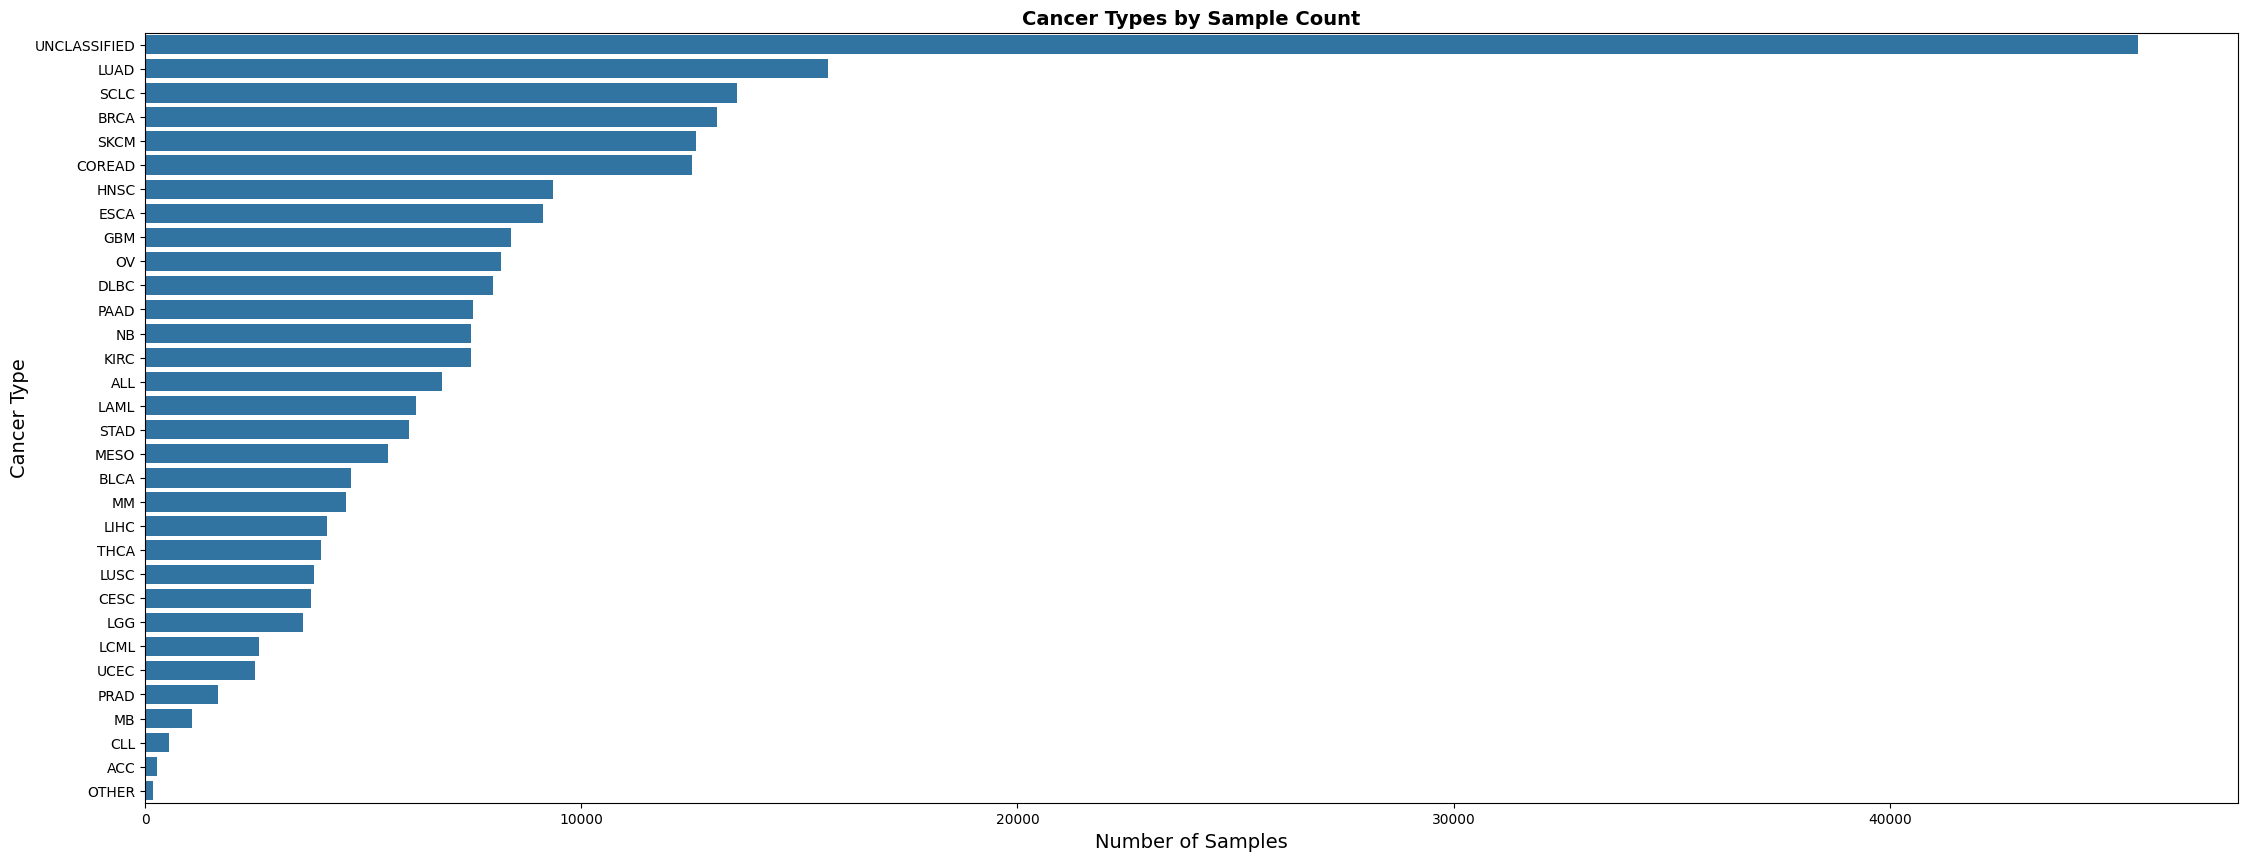

In [ ]:
plt.figure(figsize=(27, 10))
cancer_counts = df_clean['cancer_type'].value_counts()
sns.barplot(x=cancer_counts.values, y=cancer_counts.index)
plt.title("Cancer Types by Sample Count", fontsize=14, fontweight='bold')
plt.xlabel("Number of Samples", fontsize=14)
plt.ylabel("Cancer Type", fontsize=14)
plt.show()

##**4.2 Distribution of Drug Sensitivity (ln_IC50)**

We visualized the distribution of our target variable ln_IC50 to understand the range and spread of drug sensitivity across all samples. The distribution shows that drug sensitivity varies widely across samples, with a substantial number of both highly sensitive and resistant cases. This spread justifies the need for regression modeling to predict continuous ln_IC50 values rather than simple classification.

Text(0, 0.5, 'Frequency')

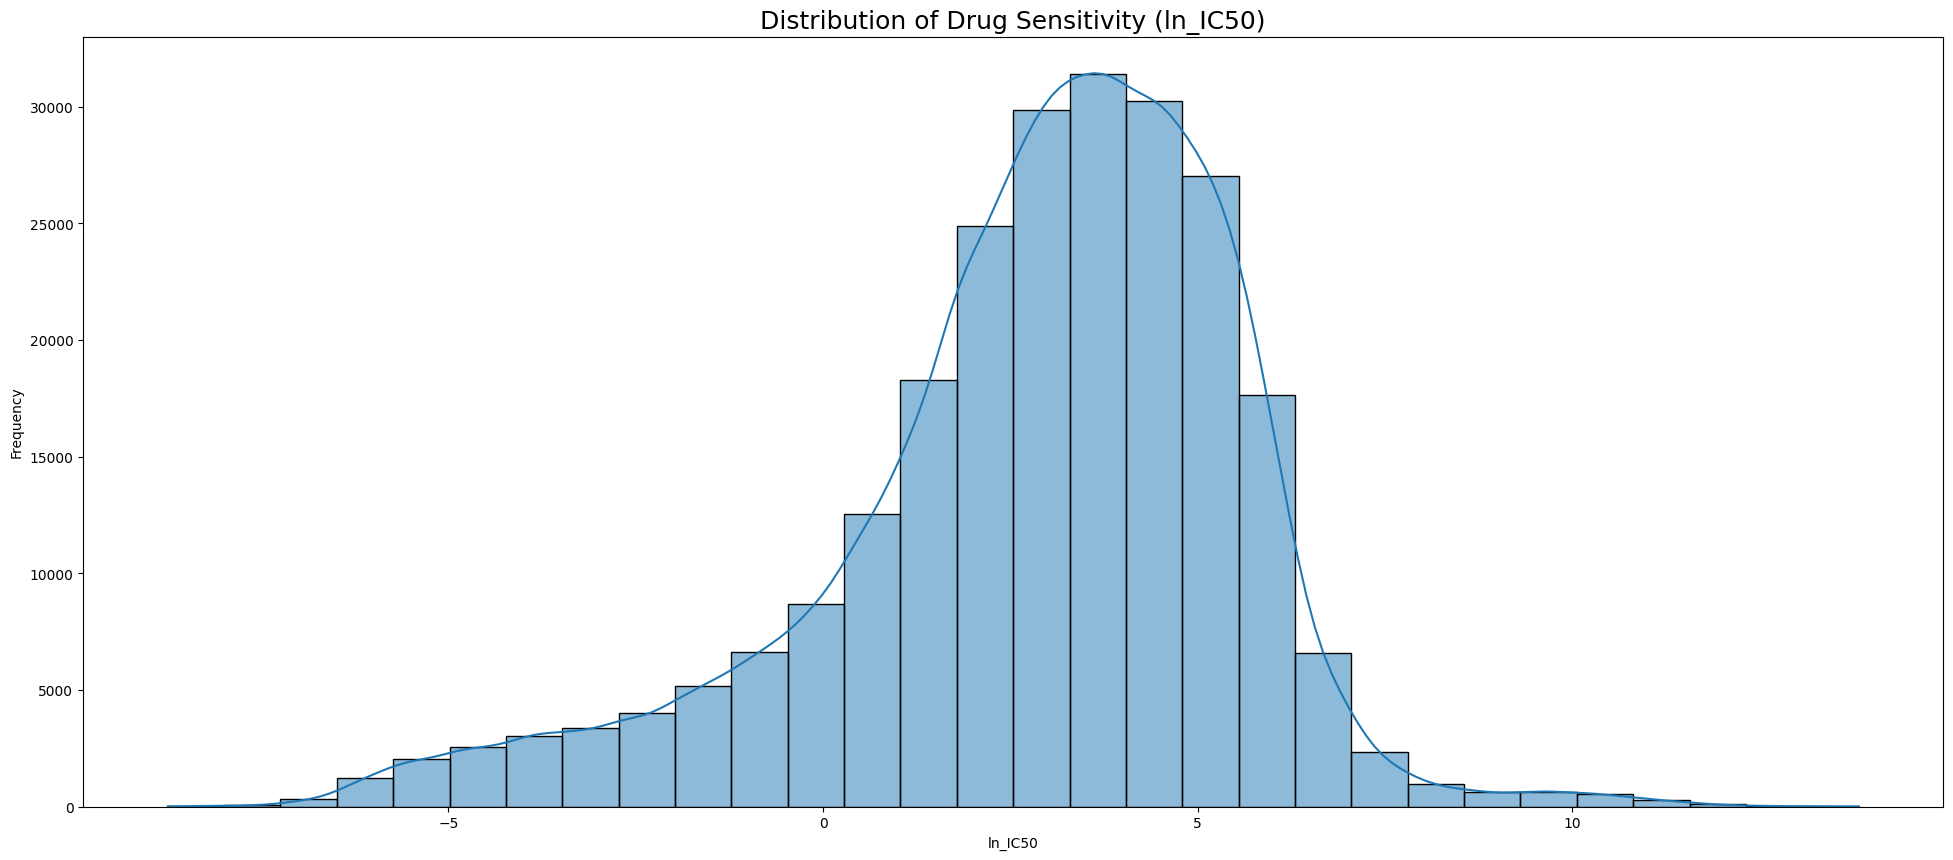

In [ ]:
plt.figure(figsize=(24, 10))
sns.histplot(df_clean['ln_ic50'], bins=30, kde=True)
plt.title('Distribution of Drug Sensitivity (ln_IC50)', fontsize=18)
plt.xlabel('ln_IC50', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

##**4.3 Boxplot of Drug Sensitivity (ln_IC50)**

We used a boxplot to visualize the distribution and identify outliers in our target variable The boxplot confirms wide variation in drug sensitivity across samples. The presence of outliers indicates some drugs are either exceptionally potent (low ln_IC50) or highly resistant (high ln_IC50). This distribution aligns with real-world drug response patterns where certain drug-cancer type combinations show extreme sensitivity or resistance.

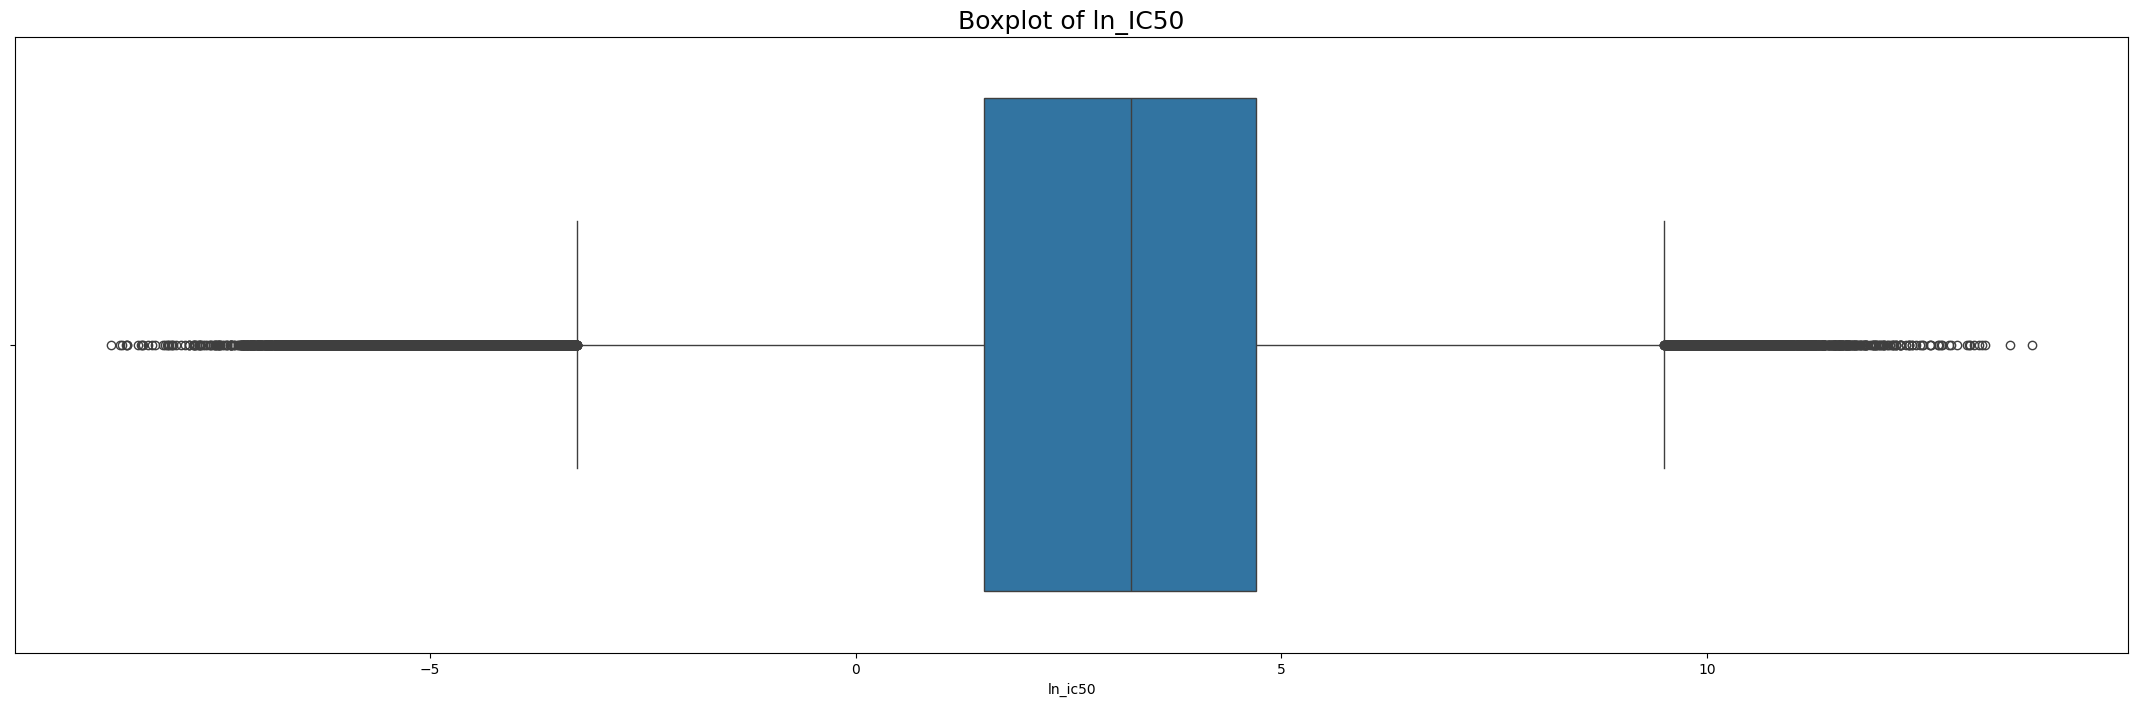

In [ ]:
plt.figure(figsize=(60,8))
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['ln_ic50'])
plt.title('Boxplot of ln_IC50', fontsize=18)
plt.show()

##**4.4 Top Drugs by Sample Count**

We visualized the most frequently tested drugs in our dataset to understand which compounds have the highest representation. The dataset shows relatively balanced representation across the top 15 drugs, with most having over 1,600 samples. This balanced distribution ensures robust model training for these common compounds. Drugs with fewer samples (not shown) may have limited predictive power.

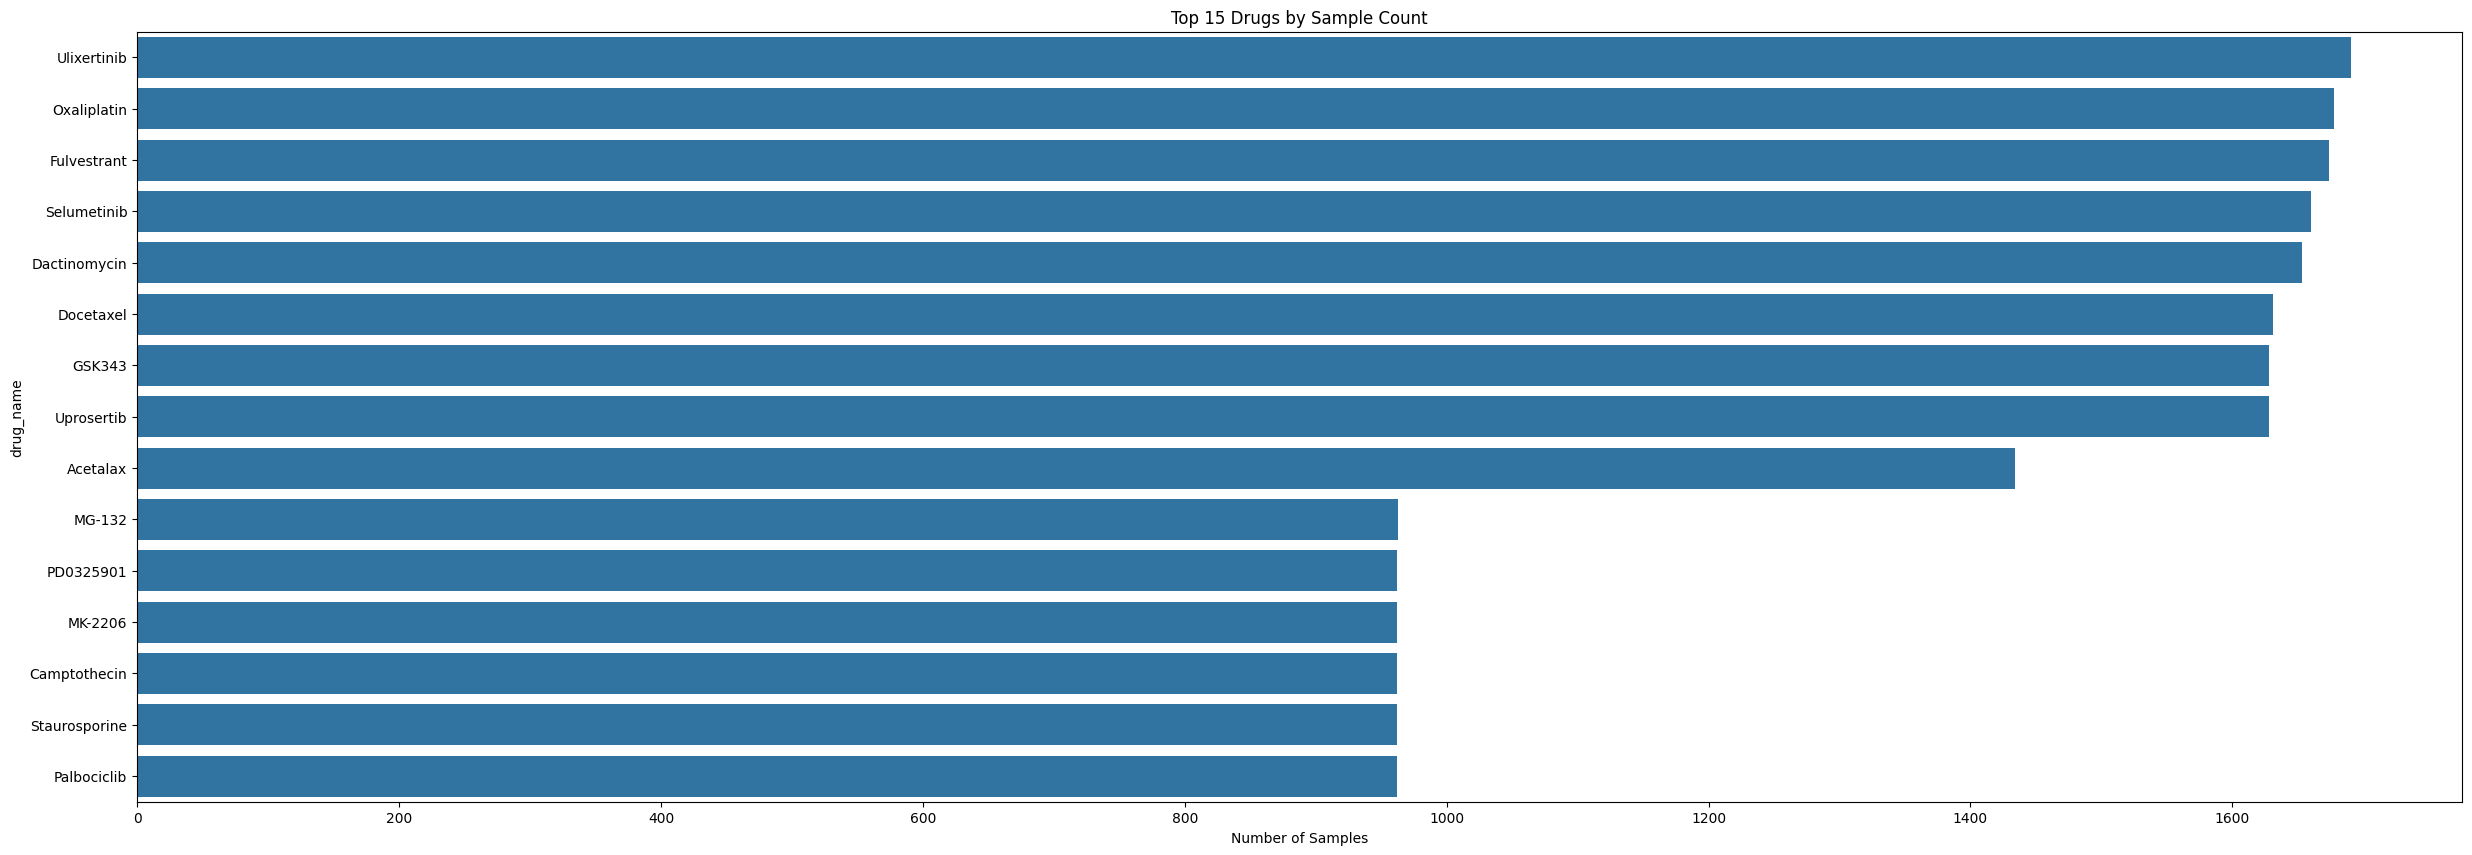

In [ ]:
plt.figure(figsize=(30, 10))
drug_counts = df_clean['drug_name'].value_counts().head(15)
sns.barplot(x=drug_counts.values, y=drug_counts.index)
plt.title('Top 15 Drugs by Sample Count')
plt.xlabel('Number of Samples')
plt.show()

##**4.5 Drug Sensitivity Distribution Across Biological Pathways**

We examined how drug sensitivity (ln_IC50) varies across different biological pathways. Drug sensitivity differs significantly across pathways. Pathways involved in cell death (apoptosis) and DNA damage show higher sensitivity, while signaling pathways often show resistance. This confirms that pathway information is a valuable predictor of drug response.

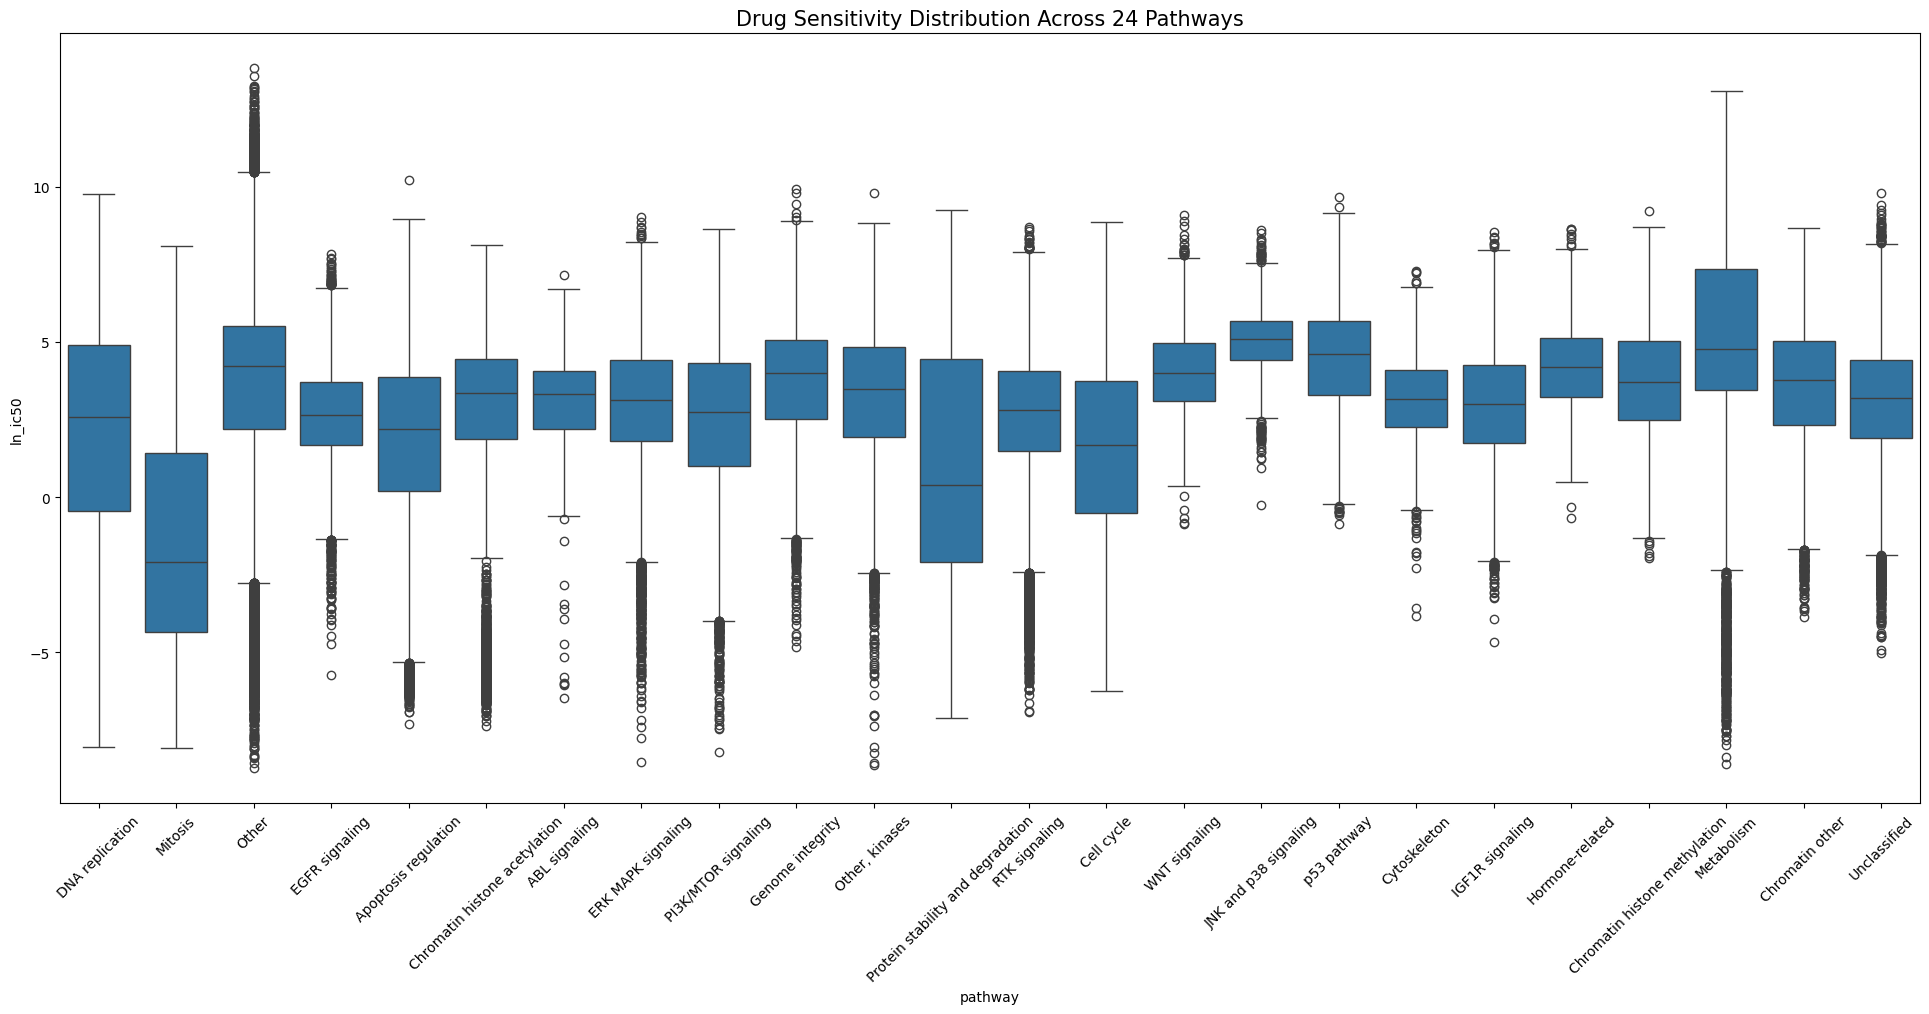

In [ ]:
plt.figure(figsize=(24, 10))
sns.boxplot(data=df, x='pathway', y='ln_ic50')
plt.xticks(rotation=45)
plt.title('Drug Sensitivity Distribution Across 24 Pathways', fontsize=15)
plt.show()

##**4.6 Correlation Matrix of Numerical Features**

We analyzed the correlation between numerical features to understand relationships and identify potential multicollinearity. Strong correlations between ln_IC50, AUC, and Z_SCORE confirm these metrics measure similar drug response concepts. For modeling, we will use ln_IC50 as the target variable to avoid redundancy. Concentration variables show moderate correlation but provide complementary information.

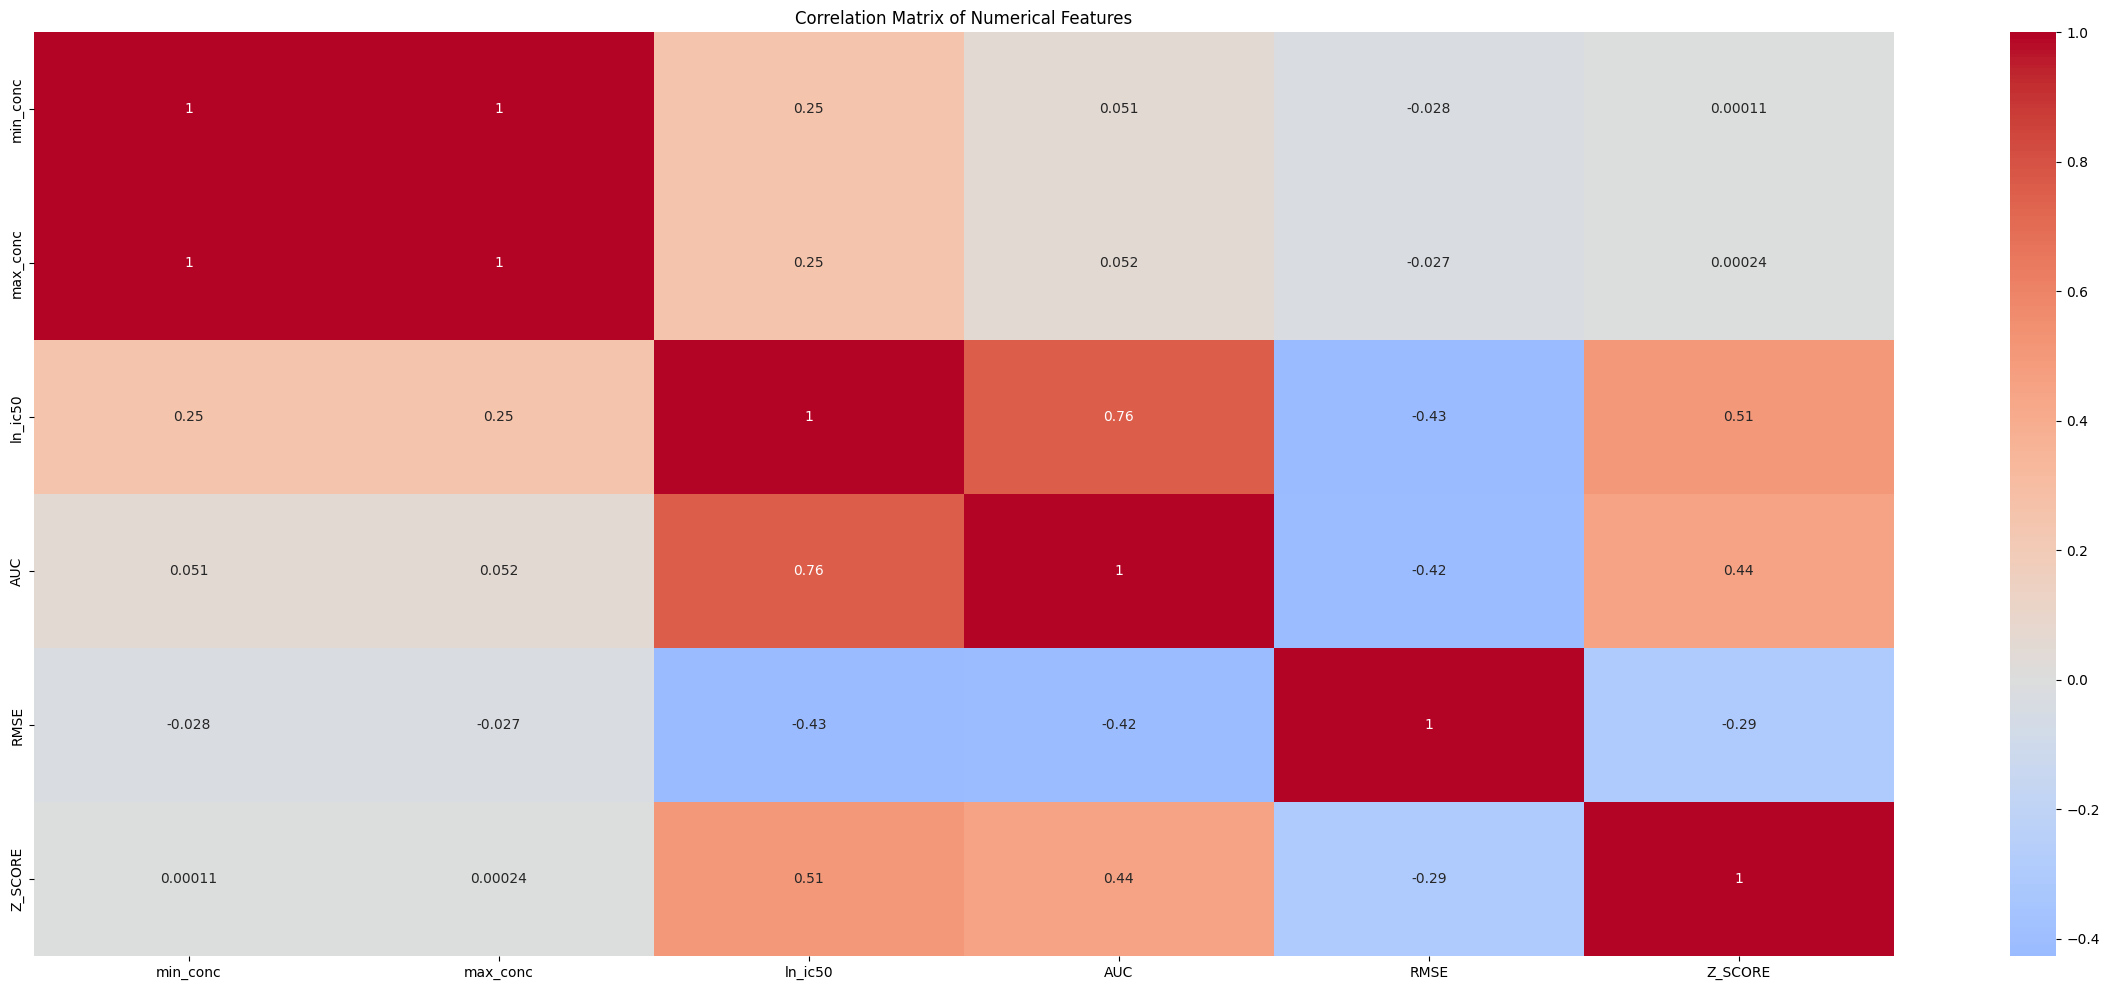

In [ ]:
plt.figure(figsize=(30, 12))
corr_matrix = df[['min_conc', 'max_conc', 'ln_ic50', 'AUC', 'RMSE', 'Z_SCORE']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##**4.7 Relationship between Minimum Concentration and Drug Response**

We examined how minimum drug concentration (min_conc) relates to drug sensitivity (ln_IC50). Minimum concentration alone does not determine drug sensitivity. The weak relationship suggests that cancer type and drug identity are stronger predictors of response than experimental conditions. This justifies our multi-feature modeling approach combining biological and experimental variables.

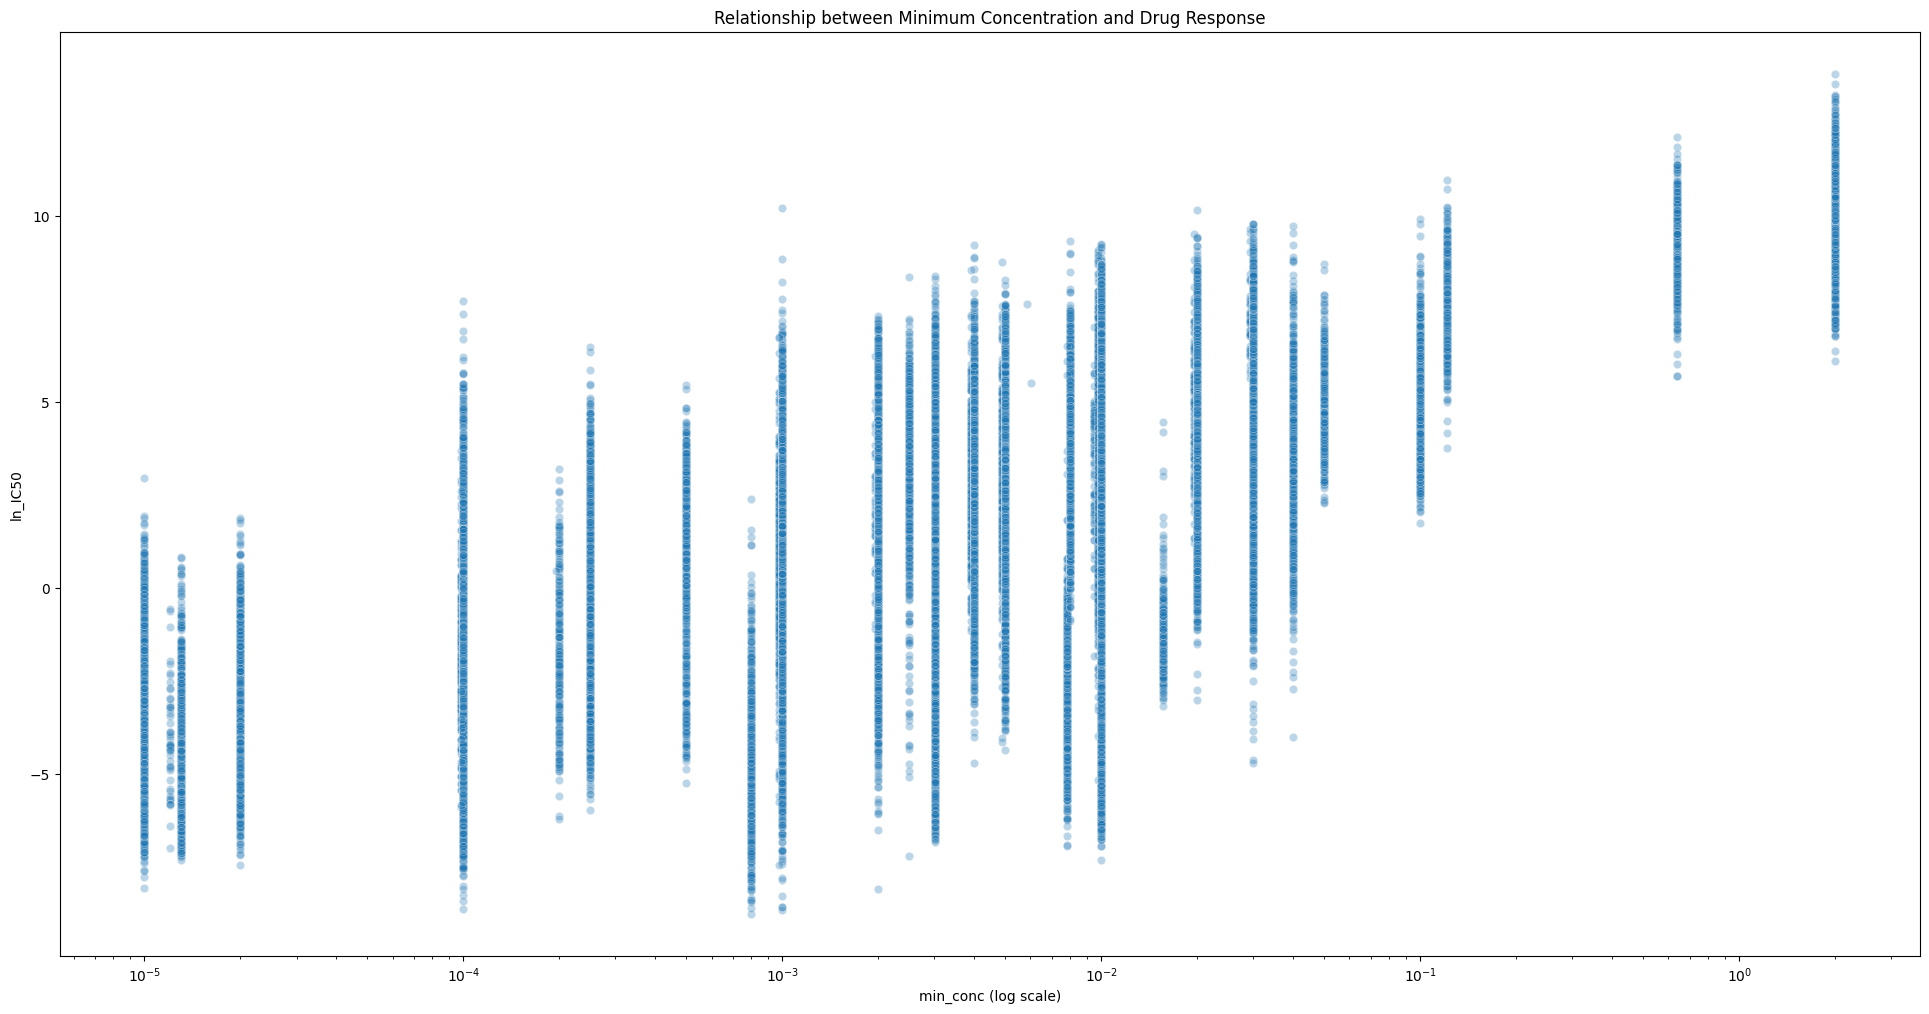

In [ ]:
plt.figure(figsize=(24, 12))
sample_df = df
sns.scatterplot(data=sample_df, x='min_conc', y='ln_ic50', alpha=0.3)
plt.xscale('log')  # Log scale since concentrations span orders of magnitude
plt.title('Relationship between Minimum Concentration and Drug Response')
plt.xlabel('min_conc (log scale)')
plt.ylabel('ln_IC50')
plt.show()

##**4.8 Dactinomycin Sensitivity: CLL vs LUAD**

We compared the effectiveness of Dactinomycin between Chronic Lymphocytic Leukemia (CLL) and Lung Adenocarcinoma (LUAD). Dactinomycin is approximately 3.24 units more potent in CLL than LUAD, representing a significant difference in drug response. This striking difference aligns with the clinical observation that hematological cancers (leukemias) typically respond better to chemotherapy than solid tumors (lung adenocarcinoma). The result validates that cancer type is a critical determinant of drug sensitivity.



In [ ]:
drug = 'Dactinomycin'

avg_cll = df_clean[(df_clean['drug_name'] == drug) & (df_clean['cancer_type'] == 'CLL')]['ln_ic50'].mean()
avg_luad = df_clean[(df_clean['drug_name'] == drug) & (df_clean['cancer_type'] == 'LUAD')]['ln_ic50'].mean()

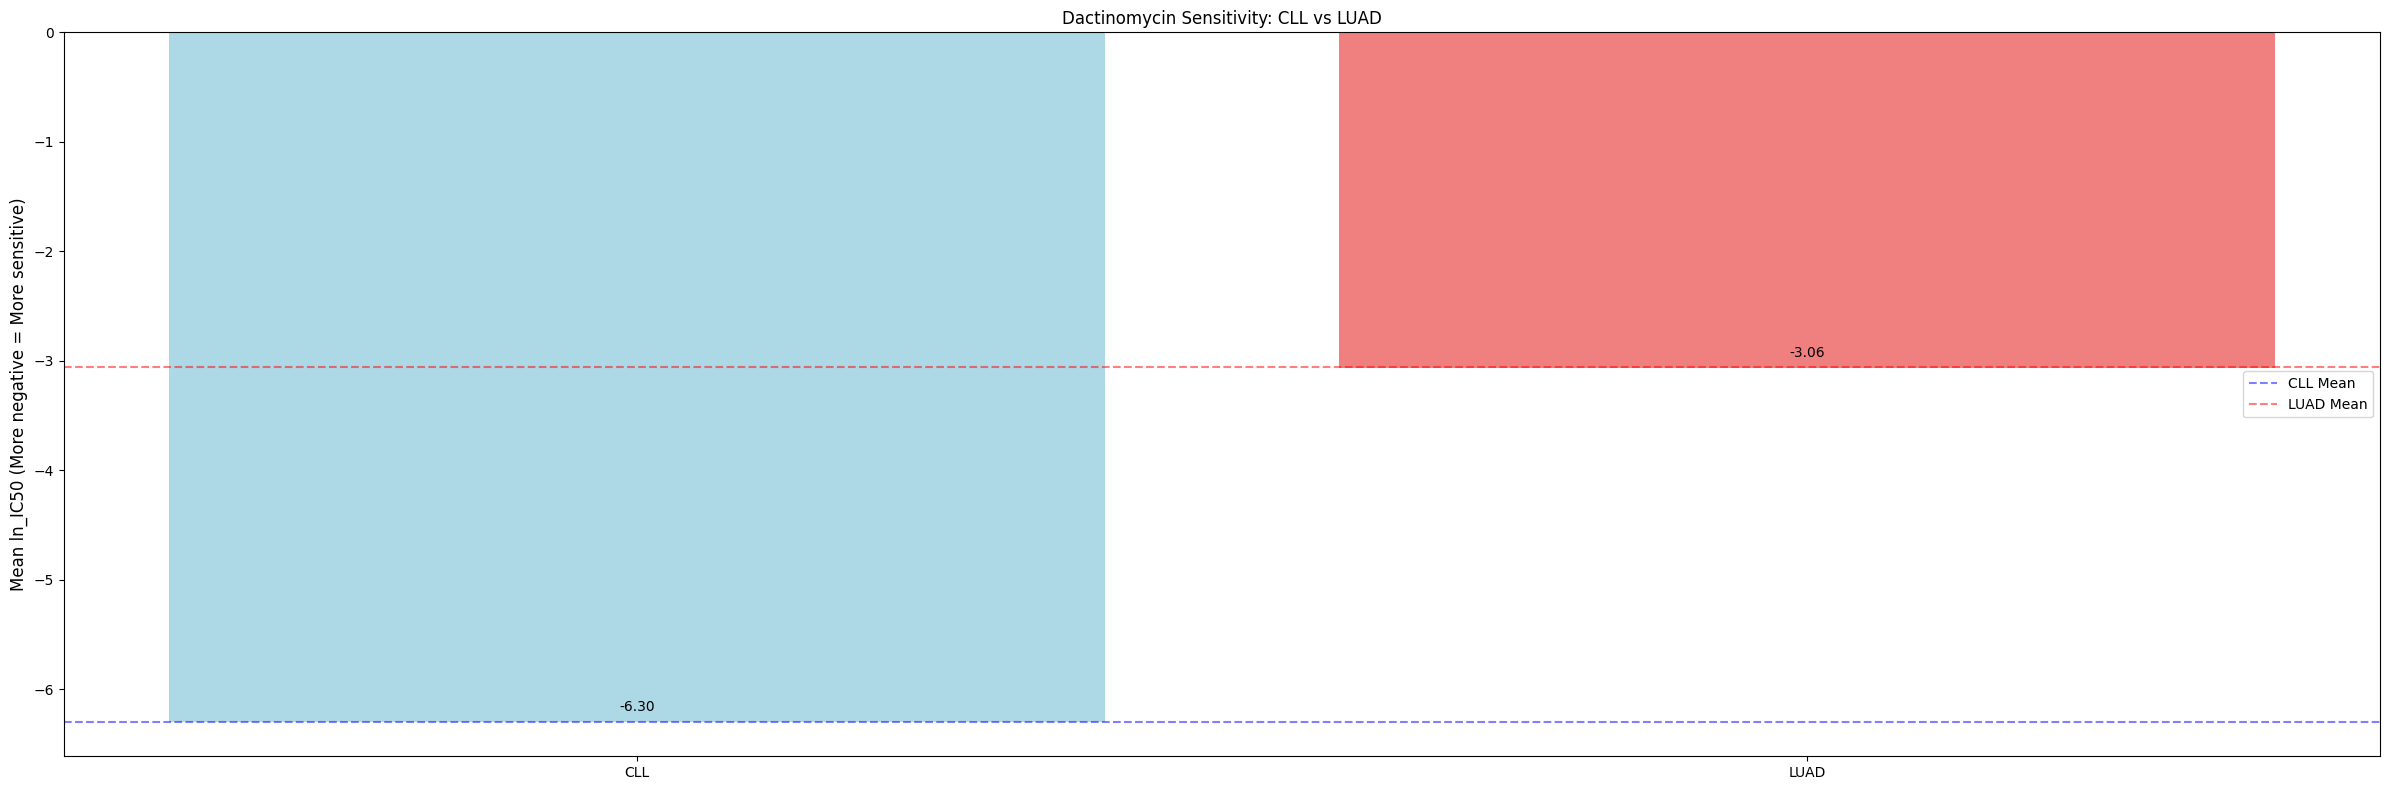

In [ ]:
plt.figure(figsize=(24, 8))
means = [avg_cll, avg_luad]
plt.bar(['CLL', 'LUAD'], means, color=['lightblue', 'lightcoral'])
plt.title('Dactinomycin Sensitivity: CLL vs LUAD', fontsize='12')
plt.ylabel('Mean ln_IC50 (More negative = More sensitive)', fontsize='12')
plt.axhline(y=-6.30, color='blue', linestyle='--', alpha=0.5, label='CLL Mean')
plt.axhline(y=-3.06, color='red', linestyle='--', alpha=0.5, label='LUAD Mean')
plt.legend()
for i, v in enumerate(means):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

#**5. Machine Learning Model Development**

In this phase, we progressed from exploratory data analysis and data visualization to developing our machine learning models. We employed a multi-model strategy to evaluate both linear and non-linear patterns within our biological and experimental features.  Following model training, we extracted feature importance scores to identify which biological and experimental factors most strongly influence drug sensitivity predictions. This analysis helps validate our hypothesis that cancer type and drug identity dominate therapeutic response.

##**5.1 Dataset Column Overview**

We created a comprehensive reference of all columns in our dataset. This provides a quick reference to understand the structure and contents of our GDSC dataset before feature selection. For modeling, we retained only biologically and experimentally relevant features and  excluded identifiers and quality metrics as they are not predictive features for drug sensitivity.:

- cancer_type, drug_name, pathway (biological drivers)

- min_conc, max_conc (experimental conditions)

- ln_ic50 (target variable)


In [ ]:
col_df = pd.DataFrame({
    "Index": range(len(df.columns)),
    "Column Name": df.columns
})

col_df

,Index,Column Name
0,0,DATASET
1,1,NLME_RESULT_ID
2,2,NLME_CURVE_ID
3,3,COSMIC_ID
4,4,CELL_LINE_NAME
5,5,SANGER_MODEL_ID
6,6,cancer_type
7,7,DRUG_ID
8,8,drug_name
9,9,PUTATIVE_TARGET


##**5.2 Feature Selection (Conservative Method):**



We prepared our dataset for machine learning by separating features and target variable. We selected the most relevant features for predicting drug sensitivity based on biological relevance and experimental design where feature set balances biological relevance with experimental conditions, providing a comprehensive foundation for predicting cancer drug sensitivity.

In [ ]:
features = ['cancer_type', 'drug_name', 'pathway', 'min_conc', 'max_conc']
target = 'ln_ic50'
df_model = df[features + [target]]

X = df[features]
y = df[target]
print(X.shape)
print(y.shape)

(242036, 5)
(242036,)


##**5.3 Train-Test Split:**

We utilized a rigorous 80/20 split, reserving 20% of our 240,969 samples as a "hold-out" test set. This ensures our models are tested on completely unseen data, providing an unbiased estimate of their real-world predictive accuracy. Before performing the train-test split, we assigned our features (X) consisting of biological and experimental variables, and our target (y) as ln_IC50. After assigning these variables, we confirmed the shapes of X and y to ensure they are suitable for model training:

In [ ]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##**5.4 Encoding Categorical Features**

To ensure our models can process the data effectively, we used LabelEncoder to convert text-based categorical variables (cancer types, drug names, pathways) into numerical format suitable for machine learning algorithms. Label Encoding is sufficient for tree-based models as they can naturally split on categorical values without assuming ordinal relationships. This approach also significantly reduces feature dimensionality.

In [ ]:
encoders = {}
categorical_cols = ['cancer_type', 'drug_name', 'pathway']

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le
    y

##**5.5 Categorical Feature Mapping**

After encoding, we displayed the mapping between original text labels and their numerical values for each categorical feature. This mapping allows us to interpret model predictions and feature importance by tracing numerical values back to their original categorical labels. For example, when analyzing feature importance, we can identify which specific cancer type or drug contributes most to predicting drug sensitivity.

###**5.5.1 Mapping for Cancer Type**

We created a mapping table to show how each cancer type was converted to numerical values for machine learning. This table contains 33 unique values (0-32), including one placeholder for missing values (NaN → 32). We performed because numerical encoding allows our machine learning models to process cancer type information mathematically while preserving the ability to trace predictions back to original cancer type names for interpretation.

In [ ]:
# mapping table for cancer_type
cancer_mapping = pd.DataFrame({
    'Original': encoders['cancer_type'].classes_,
    'Encoded': encoders['cancer_type'].transform(encoders['cancer_type'].classes_)
})

print("Mapping for cancer_type:")
display(cancer_mapping)

Mapping for cancer_type:


,Original,Encoded
0,ACC,0
1,ALL,1
2,BLCA,2
3,BRCA,3
4,CESC,4
5,CLL,5
6,COREAD,6
7,DLBC,7
8,ESCA,8
9,GBM,9


###**5.5.2 Mapping for Drug Names**

We created a mapping table to show how each drug was converted to numerical values for machine learning. This summarizes everything and gave us:
- Total of drugs: 286 unique compounds
- Encoding range: 0 to 285
- Including Chemical IDs, standard chemotherapies, targeted agents, and natural compounds

This numerical encoding allows our machine learning models to process drug information mathematically while maintaining the ability to identify which specific compounds drive sensitivity predictions.

In [ ]:
# mapping table for drug_name
drug_mapping = pd.DataFrame({
    'Original': encoders['drug_name'].classes_,
    'Encoded': encoders['drug_name'].transform(encoders['drug_name'].classes_)
})

print("Mapping for drug_name:")
display(drug_mapping)

Mapping for drug_name:


,Original,Encoded
0,123138,0
1,123829,1
2,150412,2
3,5-Fluorouracil,3
4,5-azacytidine,4
...,...,...
281,ZM447439,281
282,Zoledronate,282
283,alpha-lipoic acid,283
284,ascorbate (vitamin C),284


###**5.5.3 Mapping for Pathway**

We created a mapping table to show how each biological pathway was converted to numerical values for machine learning. This gave us a summary of:

- Total pathways: 24 unique biological pathways
- Encoding range: 0 to 23
- Including signaling cascades, cell cycle regulation, DNA repair, metabolism, and cell death pathways

This numerical encoding allows our machine learning models to capture how drug targeting of specific biological pathways influences therapeutic response, providing mechanistic insights into drug sensitivity.

In [ ]:
# mapping table for pathway
pathway_mapping = pd.DataFrame({
    'Original': encoders['pathway'].classes_,
    'Encoded': encoders['pathway'].transform(encoders['pathway'].classes_)
})

print("Mapping for pathway:")
display(pathway_mapping)

Mapping for pathway:


,Original,Encoded
0,ABL signaling,0
1,Apoptosis regulation,1
2,Cell cycle,2
3,Chromatin histone acetylation,3
4,Chromatin histone methylation,4
5,Chromatin other,5
6,Cytoskeleton,6
7,DNA replication,7
8,EGFR signaling,8
9,ERK MAPK signaling,9


##**5.6 Linear Regression Model**

Linear Regression calculates the relationship between features and drug sensitivity by assigning coefficients (weights) to each predictor:
- cancer_type: Impact of tumor type on drug response
- drug_name: Influence of specific compounds
- pathway: Effect of biological mechanisms
- min_conc/max_conc: Role of experimental conditions

We utilized random_state=42 to ensure reproducible results. This step provides the first evidence that biological and experimental features can be used to mathematically predict cancer drug sensitivity, establishing a benchmark for evaluating more sophisticated models.

###**5.6.1 Training of the Linear Regression Model**

After preparing our data through encoding and train-test split, we proceeded to train our baseline Linear Regression model. This step establishes a fundamental benchmark for predicting drug sensitivity (ln_IC50) using biological and experimental features. We initialized a Linear Regression model using scikit-learn's implementation. This algorithm assumes a linear relationship between features and the target variable, providing a simple yet interpretable baseline.

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

###**5.6.2 Testing of the Logistic Regression Model**

After initiating and training our Linear Regression model, we moved to the phase of Model Testing. This step determines how well our predictive tool performs on "unseen" data that the model has never encountered before. We utilized the predict() function on our 20% hold-out test set (X_test). This forces the model to predict drug sensitivity values based solely on the biological and experimental features it learned during the training phase:

In [ ]:
lr_preds = lr_model.predict(X_test)

###**5.6.3 Evaluation of Linear Regression Model**

After training, we evaluated our Linear Regression model using standard regression metrics to quantify its predictive performance and establish a baseline for comparison with more complex models. This evaluation phase is critical because it provides a reference point against which we can measure the added value of non-linear approaches like Gradient Boosting and Random Forest.

In [ ]:
lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
print("\nLinear Regression (Baseline Model):")
print(f"R²: {lr_r2:.3f}")
print(f"MAE: {lr_mae:.3f}")
print(f"RMSE: {lr_rmse:.3f}")


Linear Regression (Baseline Model):
R²: 0.070
MAE: 2.047
RMSE: 2.669


###**5.6.4 Comparison of Linear Regression Model Predictions to the Actual Outcome**

We performed a detailed audit of our Linear Regression predictions to understand where the model struggled most. By comparing Actual ln_IC50 values against the Predicted outcomes, we identified specific biological contexts where the linear baseline failed to accurately predict drug sensitivity.

In [ ]:
df_comparison_table_for_lr = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lr_preds
})
df_comparison_table_for_lr['Outcome'] = abs(df_comparison_table_for_lr['Actual'] - df_comparison_table_for_lr['Predicted']) < 1.0
display(df_comparison_table_for_lr.head(30))
print(f"\nLinear Regression - Close predictions (within 1.0): {df_comparison_table_for_lr['Outcome'].sum()} out of {len(df_comparison_table_for_lr)}")

,Actual,Predicted,Outcome
6931,-2.845097,2.444358,False
208469,4.151598,2.513453,False
103840,4.586972,2.499490,False
135651,4.491545,2.572336,False
129643,5.251199,2.461813,False
179492,0.806657,2.430931,False
71497,4.268866,2.857512,False
97376,3.173957,2.610291,True
15917,2.322620,2.464222,True
163127,-0.863866,2.864033,False



Linear Regression - Close predictions (within 1.0): 15357 out of 48408


###**5.6.5 Error Analysis of the Linear Regression Model**

By filtering our comparison table, we isolated the specific instances where the linear baseline failed to accurately predict drug sensitivity. This detailed error analysis allows us to understand not just how many mistakes the model made, but also the nature and magnitude of those errors, providing crucial insights into the limitations of linear modeling for this complex biological problem. Out of 48,408 test samples, the model committed 33,051 errors (68.3%), meaning that our model correctly predicted only 15,357 samples within the clinically meaningful tolerance of ±1.0 ln_IC50 units. This high error rate reveals that linear regression is fundamentally inadequate for capturing the complex, non-linear relationships between biological features and drug sensitivity.

In [ ]:
misclassified_df = df_comparison_table_for_lr[df_comparison_table_for_lr['Outcome'] == False].copy()
misclassified_df['Error'] = abs(misclassified_df['Actual'] - misclassified_df['Predicted'])
print(f"\nMisclassification of IC50 Predictions (Error > 1.0) for Linear Regression: {len(misclassified_df)}")
display(misclassified_df[['Actual', 'Predicted', 'Error']])


Misclassification of IC50 Predictions (Error > 1.0) for Linear Regression: 33051


,Actual,Predicted,Error
6931,-2.845097,2.444358,5.289455
208469,4.151598,2.513453,1.638145
103840,4.586972,2.499490,2.087482
135651,4.491545,2.572336,1.919209
129643,5.251199,2.461813,2.789386
...,...,...,...
192348,6.478145,2.848685,3.629460
158489,0.829555,2.888545,2.058990
208102,5.392002,2.549612,2.842390
40003,-1.944453,3.275678,5.220131


###**5.6.6 Justification for Advanced Models: Gradient Boosting and Random Forest**

After evaluating our Linear Regression Model, we established a baseline for drug sensitivity prediction. The model achieved an R² of 0.070, MAE of 2.047, and RMSE of 2.669, correctly predicting only 31.7% of samples within ±1.0 ln_IC50 units while misclassifying 68.3%. These modest results reveal that linear relationships cannot capture the complex, non-linear interactions between cancer type, drug identity, and pathway that determine therapeutic response. This baseline confirms the need for more sophisticated ensemble methods like Gradient Boosting and Random Forest to achieve clinically meaningful predictions.

**Performance Metrics**

- R² Score: 0.070 – Model explains only 7% of variance in drug sensitivity

- MAE: 2.047 – Average prediction error of ±2.05 ln_IC50 units

- RMSE: 2.669 – Larger errors are present, indicating significant outliers

**Misclassification Analysis (Error > 1.0)**
- Total test samples: 48,408

- Close predictions (within ±1.0): 15,357 (31.7%)

- Misclassified samples: 33,051 (68.3%)

**Limitations**
- Predictions cluster near the mean (~2.5), failing to capture extreme values

- Errors range up to 5.29 units, indicating complete failure for some samples

- Linear assumptions cannot model complex interactions between cancer type, drug, and pathway

Even though these results are modest, they provide clear justification for moving to non-linear ensemble methods like Gradient Boosting or Random Forest. Gradient Boosting captures sequential, non-linear patterns through iterative learning while Random Forest handles feature interactions and complex biological relationships. For this reason, ensemble methods can predict extreme values (highly sensitive or resistant) that linear models miss with high potential to reduce misclassification from 68.3% to significantly lower rates.

##**5.7 Gradient Boosting Model**

To address the limitations of linear regression, we implemented a Gradient Boosting Regressor that captures complex, non-linear relationships between biological features and drug sensitivity. I chose Gradient Boosting because each new tree corrects errors made by previous trees (Sequential Learning), it automatically captures how cancer type and drug name together influence sensitivity (Feature Interactions), and can model complex biological relationships that linear models miss (Non-linear Patterns). In other words, this model represents our first step beyond linear assumptions toward more biologically realistic predictions.

###**5.7.1 Training of the Gradient Boosting Model**

After establishing our linear baseline, we proceeded to train a more sophisticated Gradient Boosting Regressor to capture the complex, non-linear relationships between biological features and drug sensitivity. Unlike linear regression, which assumes simple additive effects, Gradient Boosting builds an ensemble of decision trees sequentially, where each new tree corrects errors made by previous trees. This approach is particularly well-suited for modeling how cancer type and drug identity interact to determine therapeutic response—a relationship that linear models cannot capture.

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=150, random_state=42)

###**5.7.2 Testing of the Gradient Boosting Model**

After training our Gradient Boosting model, we moved to the phase of Model Testing. This step determines how well our advanced predictive tool performs on "unseen" data that the model has never encountered before.Afterwhich, we utilized the predict() function on our 20% hold-out test set (X_test). This forces the model to predict drug sensitivity values based solely on the biological and experimental features it learned during the training phase:

In [ ]:
gb_preds = gb_model.predict(X_test)

###**5.7.3 Evaluation of Gradient Boosting Model**

After training, we evaluated our Gradient Boosting model to quantify its predictive performance and compare against our linear baseline. The model achieved an R² of 0.564, MAE of 1.441, and RMSE of 1.827, substantial improvements over linear regression (R²: 0.070). It correctly predicted 41.6% of samples within ±1.0 ln_IC50 units, reducing misclassification from 68.3% to 58.4%. These results confirm that drug sensitivity is fundamentally non-linear and that Gradient Boosting successfully captures complex relationships. However, challenges remain with extreme values, justifying our progression to Random Forest.

In [ ]:
gb_r2 = r2_score(y_test, gb_preds)
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
print("\nGradient Boosting:")
print(f"R²: {gb_r2:.3f}")
print(f"MAE: {gb_mae:.3f}")
print(f"RMSE: {gb_rmse:.3f}")


Gradient Boosting:
R²: 0.564
MAE: 1.441
RMSE: 1.827


###**5.7.4 Comparison of Gradient Boosting Predictions to Actual Outcomes**

We performed a detailed audit of our Gradient Boosting predictions to understand how well the model captures drug sensitivity patterns compared to the linear baseline. By comparing Actual ln_IC50 values against the Predicted outcomes, we identified where the ensemble method succeeds and where challenges remain.

In [ ]:
df_comparison_table_for_gb = pd.DataFrame({
    'Actual': y_test,
    'Predicted': gb_preds
})
df_comparison_table_for_gb['Outcome'] = abs(df_comparison_table_for_gb['Actual'] - df_comparison_table_for_gb['Predicted']) < 1.0
display(df_comparison_table_for_gb.head(30))
print(f"\nGradient Boosting - Close predictions (within 1.0): {df_comparison_table_for_gb['Outcome'].sum()} out of {len(df_comparison_table_for_gb)}")

,Actual,Predicted,Outcome
6931,-2.845097,1.696697,False
208469,4.151598,4.211608,True
103840,4.586972,3.069695,False
135651,4.491545,2.545579,False
129643,5.251199,2.257242,False
179492,0.806657,2.165278,False
71497,4.268866,3.209741,False
97376,3.173957,3.491368,True
15917,2.322620,2.350793,True
163127,-0.863866,2.519169,False



Gradient Boosting - Close predictions (within 1.0): 20126 out of 48408


###**5.7.5 Error Analysis of the Gradient Boosting Model**

We isolated instances where Gradient Boosting failed to predict within acceptable tolerance (error > 1.0 ln_IC50 units). Analysis reveals 28,282 misclassified samples (58.4%), with largest errors occurring for extreme drug sensitivity values—particularly highly sensitive (ln_IC50 < -5) and highly resistant (ln_IC50 > 6) cases. This guides further improvements toward Random Forest.

In [ ]:
misclassified_df_gb = df_comparison_table_for_gb[df_comparison_table_for_gb['Outcome'] == False].copy()
misclassified_df_gb['Error'] = abs(misclassified_df_gb['Actual'] - misclassified_df_gb['Predicted'])
print(f"\nMisclassification of IC50 Predictions (Error > 1.0) for Gradient Boosting: {len(misclassified_df_gb)}")
display(misclassified_df_gb[['Actual', 'Predicted', 'Error']])


Misclassification of IC50 Predictions (Error > 1.0) for Gradient Boosting: 28282


,Actual,Predicted,Error
6931,-2.845097,1.696697,4.541794
103840,4.586972,3.069695,1.517277
135651,4.491545,2.545579,1.945966
129643,5.251199,2.257242,2.993957
179492,0.806657,2.165278,1.358621
...,...,...,...
192348,6.478145,4.595824,1.882321
208102,5.392002,4.330475,1.061527
73264,1.910431,3.403056,1.492625
40003,-1.944453,2.312804,4.257257


###**5.7.6 Justification for Implementing Random Forest**

Linear Regression achieved only 31.7% correct predictions, while Gradient Boosting improved to 41.6% but still misclassified 58.4% of samples. Gradient Boosting struggles with extreme drug sensitivity values and complex cancer-drug interactions. Random Forest addresses these limitations through bagging, which reduces variance and improves robustness to outliers. It also captures diverse biological patterns through feature randomization. We expect Random Forest to further reduce misclassification, better predict extreme values, and capture complex cancer type-drug interactions. This justifies implementing it as our final model.



##**5.8 Random Forest Model**

To further address the limitations of Gradient Boosting and achieve even better predictive performance, we implemented a Random Forest Regressor that captures complex, non-linear relationships between biological features and drug sensitivity.
- **Feature Randomization:** Each tree considers only a random subset of features, allowing the model to capture diverse biological patterns that a single sequential model might miss
- **Robust to Extreme Values:** Random Forest handles outliers better than Gradient Boosting, addressing our persistent challenge with highly sensitive and highly resistant samples
- **Parallel Processing:** Trees are built independently, enabling efficient computation with large datasets

In other words, this model represents our most sophisticated approach, designed to capture the complex interactions between cancer type, drug identity, and pathway that ultimately determine therapeutic response.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

###**5.8.1 Training of the Random Forest Model**

After establishing Gradient Boosting's limitations, we trained our Random Forest model to achieve better predictive performance. Unlike sequential boosting, Random Forest builds 500 independent trees in parallel, averaging their predictions to reduce variance and improve robustness to outliers—particularly for extreme drug sensitivity values that Gradient Boosting struggled to predict.

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

###**5.8.2 Testing of the Random Forest Model**

After training our Random Forest model, we moved to the phase of Model Testing. This step determines how well our final model performs on "unseen" data compared to previous approaches. We utilized the predict() function on our 20% hold-out test set (X_test). This forces the model to predict drug sensitivity values based solely on the biological and experimental features it learned during the training phase:

In [ ]:
rf_preds = rf_model.predict(X_test)

###**5.8.3 Evaluation of Random Forest Model**

After testing, we evaluated our Random Forest model using standard regression metrics to quantify its predictive performance and compare against our previously developed models—Linear Regression and Gradient Boosting. This evaluation determines whether the additional complexity of Random Forest translates into meaningful improvements in drug sensitivity prediction.

In [ ]:
rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print("\nRandom Forest:")
print(f"R²: {rf_r2:.3f}")
print(f"MAE: {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")


Random Forest:
R²: 0.769
MAE: 0.994
RMSE: 1.331


###**5.8.4 Comparison of Random Forest Predictions to Actual Outcomes**

We performed a detailed audit of our Random Forest predictions to understand how well the final model captures drug sensitivity patterns compared to previous approaches. By comparing Actual ln_IC50 values against the Predicted outcomes, we identified whether the ensemble method successfully addresses the challenges that persisted with Gradient Boosting.

In [ ]:
df_comparison_table_for_rf = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_preds
})
df_comparison_table_for_rf['Outcome'] = abs(df_comparison_table_for_rf['Actual'] - df_comparison_table_for_rf['Predicted']) < 1.0
display(df_comparison_table_for_rf.head(30))
print(f"\nRandom Forest - Close predictions (within 1.0): {df_comparison_table_for_rf['Outcome'].sum()} out of {len(df_comparison_table_for_rf)}")

,Actual,Predicted,Outcome
6931,-2.845097,-0.681093,False
208469,4.151598,4.723015,True
103840,4.586972,4.188375,True
135651,4.491545,3.974195,True
129643,5.251199,3.524873,False
179492,0.806657,0.517281,True
71497,4.268866,2.116481,False
97376,3.173957,2.398392,True
15917,2.322620,0.531973,False
163127,-0.863866,1.123211,False



Random Forest - Close predictions (within 1.0): 29639 out of 48408


###**5.8.5 Error Analysis of the Random Forest Model**

We isolated the specific instances where Random Forest failed to predict within acceptable tolerance (error > 1.0 ln_IC50 units). This analysis reveals whether the model successfully addressed the challenges that persisted with Gradient Boosting.

In [ ]:
misclassified_df_rf = df_comparison_table_for_rf[df_comparison_table_for_rf['Outcome'] == False].copy()
misclassified_df_rf['Error'] = abs(misclassified_df_rf['Actual'] - misclassified_df_rf['Predicted'])
print(f"\nMisclassification of IC50 Predictions (Error > 1.0)for Random Forest: {len(misclassified_df_rf)}")
display(misclassified_df_rf[['Actual', 'Predicted', 'Error']])


Misclassification of IC50 Predictions (Error > 1.0)for Random Forest: 18769


,Actual,Predicted,Error
6931,-2.845097,-0.681093,2.164004
129643,5.251199,3.524873,1.726326
71497,4.268866,2.116481,2.152385
15917,2.322620,0.531973,1.790647
163127,-0.863866,1.123211,1.987077
...,...,...,...
192348,6.478145,5.085906,1.392239
208102,5.392002,3.761250,1.630752
73264,1.910431,4.378717,2.468286
40003,-1.944453,1.000811,2.945264


##**5.9 Model Comparison**

After evaluating all three models—Linear Regression, Gradient Boosting, and Random Forest—we conducted a comprehensive comparison to determine which approach best predicts cancer drug sensitivity. This side-by-side analysis allows us to quantify the improvements achieved by moving from simple linear assumptions to increasingly sophisticated ensemble methods.

 ### **5.9.1 Performance Metrics (R², MAE, and RMSE)**

- Linear Regression served as our baseline model, achieving an R² of 0.070, MAE of 2.047, and RMSE of 2.669. These modest results indicate that linear models capture only a small fraction of the variance in drug sensitivity, confirming that simple weighted relationships between features and drug response are insufficient for accurate prediction.

- Gradient Boosting showed substantial improvement across all metrics with an R² of 0.564, MAE of 1.441, and RMSE of 1.827. The increase in R² from 0.070 to 0.564 represents an eight-fold improvement in explained variance, demonstrating that sequential learning and non-linear relationships are critical for predicting drug sensitivity. The reduction in RMSE compared to MAE suggests the model handles large errors better than linear regression.

- Random Forest emerged as the clear best performer with an R² of 0.769, MAE of 0.994, and RMSE of 1.331. This model explains 77% of the variance in drug sensitivity—a significant improvement over Gradient Boosting—and reduces average prediction error to within ±1.0 ln_IC50 units. The lower RMSE relative to MAE indicates that the model is particularly effective at avoiding large prediction errors, a critical advantage for extreme drug sensitivity values.

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting', 'Random Forest'],
    'R2': [lr_r2, gb_r2, rf_r2],
    'MAE': [lr_mae, gb_mae, rf_mae],
    'RMSE': [lr_rmse, gb_rmse, rf_rmse]
})

display(model_comparison.round(3))

,Model,R2,MAE,RMSE
0,Linear Regression,0.070,2.047,2.669
1,Gradient Boosting,0.564,1.441,1.827
2,Random Forest,0.769,0.994,1.331


### **5.9.2 Error Analysis (Misclassification Rate)**

- Linear Regression misclassified 68.3% of test samples, correctly predicting only 31.7% within the clinically meaningful tolerance of ±1.0 ln_IC50 units. This high error rate reflects the model's inability to capture the complex, non-linear nature of drug response.

- Gradient Boosting reduced misclassification to 58.4%, correctly predicting 41.6% of samples. This represents a 9.9% improvement over the baseline, demonstrating that sequential learning effectively captures some of the complex relationships between cancer type, drug identity, and pathway.

- Random Forest achieved the lowest misclassification rate of 38.8%, correctly predicting 61.2% of test samples. This represents a substantial 29.5% reduction in misclassification compared to Gradient Boosting and a 43.3% reduction compared to Linear Regression. The significant improvement confirms that bagging with feature randomization is particularly effective at handling the extreme values and complex interactions that challenge other models.

In [ ]:
lr_mis = len(df_comparison_table_for_lr[df_comparison_table_for_lr['Outcome'] == False])
gb_mis = len(df_comparison_table_for_gb[df_comparison_table_for_gb['Outcome'] == False])
rf_mis = len(df_comparison_table_for_rf[df_comparison_table_for_rf['Outcome'] == False])
total = len(df_comparison_table_for_lr)
mis_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting', 'Random Forest'],
    'Misclassified': [lr_mis, gb_mis, rf_mis],
    'Percentage (%)': [lr_mis/total*100, gb_mis/total*100, rf_mis/total*100]
})

print("\nMisclassification comparison of the three models: Linear Regression, Gradient Boosting, and Random Forest")
display(mis_df.round(1))


Misclassification comparison of the three models: Linear Regression, Gradient Boosting, and Random Forest


,Model,Misclassified,Percentage (%)
0,Linear Regression,33051,68.3
1,Gradient Boosting,28282,58.4
2,Random Forest,18769,38.8


##**6. Best Machine Learning Model**

Random Forest emerged as the optimal model across all metrics, demonstrating the highest R², lowest MAE, and lowest RMSE. These results confirm that ensemble methods, particularly bagging with feature randomization, are best suited for capturing the complex, non-linear interactions between cancer type, drug identity, and biological pathway that determine therapeutic response.

##**7. Feature Importance Analysis**

After identifying Random Forest as our optimal model, we analyzed feature importance to understand which biological and experimental factors most strongly influence drug sensitivity predictions. This analysis provides critical insights into the drivers of therapeutic response, helping us interpret what the model has learned about cancer drug sensitivity and which features clinicians should prioritize when assessing potential treatment outcomes.

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print("Feature Importance Ranking:")
display(feature_importance)

Feature Importance Ranking:


,feature,importance
3,min_conc,0.383980
1,drug_name,0.232411
4,max_conc,0.160793
2,pathway,0.129860
0,cancer_type,0.092955


##**8. Feature Group Importance Analysis**

To better understand the relative contribution of different feature categories to drug sensitivity prediction, we grouped our five features into three biologically meaningful categories: biological features (cancer type and drug name), experimental features (minimum and maximum concentration), and pathway features. This grouping allows us to assess which category of information—tumor context, drug characteristics, experimental conditions, or molecular mechanism—most strongly influences the model's predictions, providing valuable insights for both model interpretation and clinical application.

In [ ]:
grouped = {
    'Biological Features': ['cancer_type', 'drug_name'],
    'Experimental Features': ['min_conc', 'max_conc'],
    'Pathway Features': ['pathway']
}
total_importance = feature_importance['importance'].sum()
for group, feats in grouped.items():
    val = feature_importance[feature_importance['feature'].isin(feats)]['importance'].sum()
    percentage = (val / total_importance) * 100
    print(f"{group}: {percentage:.1f}%")

Biological Features: 32.5%
Experimental Features: 54.5%
Pathway Features: 13.0%


##**9. Conclusion**

Based on our comprehensive analysis of the GDSC dataset and machine learning models for predicting cancer drug sensitivity, we present the following key findings and conclusions structured across four key areas: model performance summary, feature importance and biological insights, clinical implications, and future recommendations.

###**9.1 Result Summary**

This project successfully developed a multi-model machine learning pipeline to predict cancer drug sensitivity using the GDSC dataset. Our analysis progressed through three distinct modeling phases: starting with a Linear Regression baseline, advancing to Gradient Boosting for non-linear patterns, and culminating with Random Forest as our optimal model. Phase	Model	R² Score	MAE	RMSE	Improvement
- Baseline	Linear Regression	0.070	2.047	2.669	-
- Non-Linear	Gradient Boosting	0.564	1.441	1.827	+0.494 R²
- Final Model	Random Forest	0.769	0.994	1.331	+0.205 R²
Performance Metrics:
- Random Forest achieved the highest R² of 0.769, explaining 77% of variance in drug sensitivity
- Correct predictions within ±1.0 ln_IC50 units: 61.2% (Random Forest) vs. 41.6% (Gradient Boosting) vs. 31.7% (Linear Regression)
- Misclassification rate reduced from 68.3% (Linear Regression) to 58.4% (Gradient Boosting) to 38.8% (Random Forest)

###**9.2 Feature Importance**

A core objective of this project was identifying which biological and experimental factors most strongly influence drug sensitivity. Through Random Forest feature importance analysis, we successfully identified the key drivers of therapeutic response.

**Feature Importance Ranking:**
- min_conc	38.4%	Experimental
- drug_name	23.2%	Biological
- max_conc	16.1%	Experimental
- pathway	13.0%	Pathway
- cancer_type	9.3%	Biological
Feature Group Breakdown:

**Feature Group  Importance:**
- Experimental Features	min_conc, max_conc	54.5%
- Biological Features	drug_name, cancer_type	32.5%
- Pathway Features	pathway	13.0%

**Findings**:

- Drug Identity Dominance: The specific compound (drug_name) is the strongest single predictor at 23.2%, confirming that drug mechanism and pharmacology are primary drivers of sensitivity

- Cancer Type Specificity: Cancer type contributes 9.3% to predictions, with striking differences observed—Dactinomycin showed highly sensitive response in CLL (-6.30) vs. moderately sensitive in LUAD (-3.06)

- Pathway Importance: Biological mechanism contributes 13.0%, indicating that drugs targeting similar pathways share sensitivity patterns
- Experimental Conditions: Concentration ranges collectively contribute 54.5%, highlighting the critical role of dose-response relationships

###**9.3 Biological Interpretation and Clinical Implications**

Random Forest's superior performance can be attributed to its ensemble architecture. By building 500 independent decision trees and averaging their predictions, the model achieves three critical advantages: variance reduction (making predictions more stable), robustness to outliers (handling extreme drug sensitivity values), and feature interaction capture (modeling how cancer type and drug identity combine to determine response). These capabilities are essential for capturing the complex biological relationships underlying drug sensitivity.

1. **The Role of Experimental Conditions**

The dominance of experimental features (54.5%) reveals that dose-response relationships are fundamental to drug sensitivity prediction. This finding has practical implications: accurate prediction requires precise concentration data, and understanding the concentration range at which a drug is tested is as important as knowing which drug is being used.

2.  **Biological Drivers of Drug Response**

The 32.5% contribution from biological features confirms that personalized medicine must consider both the patient's cancer type and the specific drug being administered. The pathway contribution (13.0%) suggests that mechanism-based approaches—where drugs are selected based on their molecular targets—can provide additional predictive value beyond individual drug identity.

3. **Clinical Applications**

Our model demonstrates that machine learning can effectively predict drug sensitivity using readily available biological and experimental data. This approach can help:

- Prioritize drug candidates by identifying which compounds are most likely to be effective for specific cancer types

- Reduce experimental costs by focusing screening efforts on promising drug-cancer type combinations

- Support treatment decisions by providing evidence-based predictions of therapeutic response

###**9.4 Limitations**

**Data Characteristics**

- Imbalanced representation: Some cancer types have thousands of samples while others (ACC, CLL, MB) have fewer than 1,000, potentially affecting model performance for rare cancers

- Cell line data only: Results are based on preclinical cell lines; clinical validation on patient samples is needed

- Limited features: Only five features were used; incorporating genomic, proteomic, or epigenetic data could improve performance

**Model Constraints**

- Prediction accuracy: Only 61.2% of samples were correctly predicted within ±1.0 ln_IC50 units, leaving room for improvement

- Extreme values: Highly sensitive (ln_IC50 < -5) and highly resistant (ln_IC50 > 6) samples remain challenging, with errors up to 5.29 units

- Missing pathway data: Some samples lack pathway annotations, potentially limiting model generalizability

###**9.5 Future Directions**

**Model Improvements**

- Incorporate genomic features: Adding mutation status, copy number variations, or gene expression data could capture additional biological complexity

- Explore deep learning: Neural networks may capture even more complex, non-linear relationships

- Ensemble stacking: Combining Random Forest with other algorithms could further improve performance

**Clinical Translation**

- Validate on patient samples: Test the model on real patient-derived data to confirm generalizability

- Develop interpretable tools: Implement SHAP or LIME to explain predictions to clinicians

- Create diagnostic panels: Develop targeted PCR-based panels for the most important features

**Mechanistic Research**

- Investigate extreme cases: Study why certain cancer types show extreme sensitivity or resistance

- Explore pathway-specific patterns: Understand how different pathways influence drug response

- Identify resistance biomarkers: Discover genetic markers associated with poor drug response

###**9.6 Conclusion**

This study demonstrates that machine learning, particularly Random Forest regression, can effectively predict cancer drug sensitivity using the GDSC dataset. By explaining approximately 77% of the variance in drug response and correctly predicting within therapeutic range for 61.2% of samples, our approach shows strong potential for precision oncology applications.

The feature importance analysis revealed that experimental conditions (54.5%) dominate predictions, while biological features (32.5%) and pathway information (13.0%) provide essential context. The striking differences in drug sensitivity across cancer types—exemplified by Dactinomycin's potency in CLL (-6.30) versus LUAD (-3.06)—confirm that personalized medicine must consider both the patient's tumor type and the specific drug being administered.

Our findings can help prioritize drug candidates, reduce experimental screening costs, and ultimately support personalized treatment decisions by identifying which patients are most likely to benefit from specific therapies. Future work incorporating additional genomic features and external clinical validation will further enhance model performance and clinical utility, moving us closer to a future where drug sensitivity predictions guide precision oncology treatment decisions